In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from IPython.display import display
import os
# ignore warnings
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.1f}'.format
%matplotlib inline
plotsize = (13, 5)

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Superstore.xls")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,262.0,2,0.0,41.9
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9,3,0.0,219.6
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6,2,0.0,6.9
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.6,5,0.5,-383.0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.4,2,0.2,2.5


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.shape

(9994, 21)

the data have been input and the columns are referenced by a Pandas Index
object. There are two Date variables (Order Date and Ship Date), variables for customer and region, product type variables (Category, Sub-Category, Product Name), etc.


### Simplify Time Series Data
We will start by simplifying the input data a bit to explore data types. To do so, we will look at Total Sales by Order Date and Category. This allows us to look a Time Series dataset with multiple time series.

In [ ]:
variables = ['Order Date','Category', 'Sales']
group_variable = variables[:2]
outcome_variable = variables[2]

In [ ]:
variables_grouped = df.groupby(group_variable)[outcome_variable].sum().reset_index()

In [ ]:
print("Columns:",variables_grouped.columns)

Columns: Index(['Order Date', 'Category', 'Sales'], dtype='object')


In [ ]:
print("Index:",variables_grouped.columns)

Index: Index(['Order Date', 'Category', 'Sales'], dtype='object')


In [ ]:
variables_grouped.head()

,Order Date,Category,Sales
0,2014-01-03,Office Supplies,16.4
1,2014-01-04,Office Supplies,288.1
2,2014-01-05,Office Supplies,19.5
3,2014-01-06,Furniture,"2,573.8"
4,2014-01-06,Office Supplies,685.3


In [ ]:
variables_grouped.dtypes

Order Date    datetime64[ns]
Category              object
Sales                float64
dtype: object

In [ ]:
variables_grouped["Order Date"].min(),variables_grouped["Order Date"].max()

(Timestamp('2014-01-03 00:00:00'), Timestamp('2017-12-30 00:00:00'))

SO we have a clear 4 Years of Sales Data

We Check for the available Categories

In [ ]:
print(variables_grouped.head())

  Order Date         Category   Sales
0 2014-01-03  Office Supplies    16.4
1 2014-01-04  Office Supplies   288.1
2 2014-01-05  Office Supplies    19.5
3 2014-01-06        Furniture 2,573.8
4 2014-01-06  Office Supplies   685.3


Lets Find the Unique Catergories

In [ ]:
print("Unique Categories: ", variables_grouped['Category'].unique())

Unique Categories:  ['Office Supplies' 'Furniture' 'Technology']


## Setting Index Using Existing Variable
We often want to set an Index explicitly, or manipulate an Index, for working with Time Series data. The Pandas DateTime Index is useful here, although it is often useful to standardize the  index by ensuring all relevant time periods are included only once. Our data violate this condition for two reasons: (1) Multiple values for a given period (due to multiple categories) and (2) Missing days (for daily data). We will fix both of these issues below, and explore some useful Datetime functionality.

In [ ]:
variables_grouped.set_index('Order Date',inplace=True)

In [ ]:
variables_grouped.head()

,Category,Sales
Order Date,,
2014-01-03,Office Supplies,16.4
2014-01-04,Office Supplies,288.1
2014-01-05,Office Supplies,19.5
2014-01-06,Furniture,"2,573.8"
2014-01-06,Office Supplies,685.3


In [ ]:
print(variables_grouped.index)

DatetimeIndex(['2014-01-03', '2014-01-04', '2014-01-05', '2014-01-06',
               '2014-01-06', '2014-01-06', '2014-01-07', '2014-01-07',
               '2014-01-09', '2014-01-09',
               ...
               '2017-12-27', '2017-12-28', '2017-12-28', '2017-12-28',
               '2017-12-29', '2017-12-29', '2017-12-29', '2017-12-30',
               '2017-12-30', '2017-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=2861, freq=None)


## Subsetting data
We now have a __DatetimeIndex__ and we can use it to select data subsets:

In [ ]:
print(variables_grouped['2017'].head())

                   Category  Sales
Order Date                        
2017-01-01        Furniture  975.5
2017-01-01  Office Supplies  506.3
2017-01-02        Furniture  913.4
2017-01-02  Office Supplies  453.8
2017-01-02       Technology  712.3


We divide the data into subsets and here we proceed with the Category : Furniture

In [ ]:
furniture = variables_grouped.loc[variables_grouped['Category']=='Furniture']


In [ ]:
furniture.head(10)

,Category,Sales
Order Date,,
2014-01-06,Furniture,"2,573.8"
2014-01-07,Furniture,76.7
2014-01-10,Furniture,51.9
2014-01-11,Furniture,9.9
2014-01-13,Furniture,879.9
2014-01-14,Furniture,62.0
2014-01-16,Furniture,127.1
2014-01-19,Furniture,181.5
2014-01-20,Furniture,"1,413.5"


Now we extract the date time components like month, year ,day of the week ,quater etc

In [ ]:
print("Day:",variables_grouped.index.day)
print("Week:",variables_grouped.index.week)

Day: Int64Index([ 3,  4,  5,  6,  6,  6,  7,  7,  9,  9,
            ...
            27, 28, 28, 28, 29, 29, 29, 30, 30, 30],
           dtype='int64', name='Order Date', length=2861)
Week: Int64Index([ 1,  1,  1,  2,  2,  2,  2,  2,  2,  2,
            ...
            52, 52, 52, 52, 52, 52, 52, 52, 52, 52],
           dtype='int64', name='Order Date', length=2861)


In [ ]:
#variables_grouped['Day of Week']= variables_grouped.index.dayofweek # Day of Week: Monday=0, Sunday=6


In [ ]:
print(variables_grouped.head())

                   Category   Sales
Order Date                         
2014-01-03  Office Supplies    16.4
2014-01-04  Office Supplies   288.1
2014-01-05  Office Supplies    19.5
2014-01-06        Furniture 2,573.8
2014-01-06  Office Supplies   685.3


## Pivoting Data:

Because there are multiple categories, we have multiple Time Series to analyze. As a result, our __DatetimeIndex__ does not uniquely identify an observation. To uniquely identify observations, we can either add categorical variables to the Index, or set a Pandas DateTimeIndex with separate columns for each series.



In [ ]:
variables_grouped.reset_index(inplace=True)
sales_pivot = variables_grouped.pivot(index='Order Date', columns='Category', values='Sales')
sales_pivot.head()

Category,Furniture,Office Supplies,Technology
Order Date,,,
2014-01-03,NaN,16.4,NaN
2014-01-04,NaN,288.1,NaN
2014-01-05,NaN,19.5,NaN
2014-01-06,"2,573.8",685.3,"1,147.9"
2014-01-07,76.7,10.4,NaN


We  set the missing data (displayed as NaN) to 0

In [ ]:
sales = variables_grouped.set_index(['Order Date', 'Category']).unstack('Category').fillna(0)


In [ ]:
sales.head()

Sales                           
Category   Furniture Office Supplies Technology
Order Date                                     
2014-01-03       0.0            16.4        0.0
2014-01-04       0.0           288.1        0.0
2014-01-05       0.0            19.5        0.0
2014-01-06   2,573.8           685.3    1,147.9
2014-01-07      76.7            10.4        0.0

In [ ]:
print(sales.index)
print('\nUnique dates in our data: ', len(sales.index.unique()), 'Days')

DatetimeIndex(['2014-01-03', '2014-01-04', '2014-01-05', '2014-01-06',
               '2014-01-07', '2014-01-09', '2014-01-10', '2014-01-11',
               '2014-01-13', '2014-01-14',
               ...
               '2017-12-21', '2017-12-22', '2017-12-23', '2017-12-24',
               '2017-12-25', '2017-12-26', '2017-12-27', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', name='Order Date', length=1237, freq=None)

Unique dates in our data:  1237 Days


Since we have now created a column for each category, we can see there no longer repeated values in the Datetime Index.

## Generating a complete Index and Setting Frequency
Since we are using daily data, we would like to set a daily frequency. We see our data has a length of 1238 days. By subtracting the smallest date from the largest date, we can tell there are some days missing:

In [ ]:
print('\nUnique dates in our data: ', len(sales.index.unique()), 'Days')
our_date_range = sales.index.max() - sales.index.min()

# Calculate number of days in date range
print('Total days in our date range:', our_date_range.days, 'Days')
#date_range = pd.date_range(min(sales.index), max(sales.index))


Unique dates in our data:  1237 Days
Total days in our date range: 1457 Days


In [ ]:
new_index = pd.date_range(sales.index.min(), sales.index.max())
print(new_index)

DatetimeIndex(['2014-01-03', '2014-01-04', '2014-01-05', '2014-01-06',
               '2014-01-07', '2014-01-08', '2014-01-09', '2014-01-10',
               '2014-01-11', '2014-01-12',
               ...
               '2017-12-21', '2017-12-22', '2017-12-23', '2017-12-24',
               '2017-12-25', '2017-12-26', '2017-12-27', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', length=1458, freq='D')


We want to use zero for days without sales data

In [ ]:
sales_new = sales.reindex(new_index, fill_value=0)

In [ ]:
sales_new.index

DatetimeIndex(['2014-01-03', '2014-01-04', '2014-01-05', '2014-01-06',
               '2014-01-07', '2014-01-08', '2014-01-09', '2014-01-10',
               '2014-01-11', '2014-01-12',
               ...
               '2017-12-21', '2017-12-22', '2017-12-23', '2017-12-24',
               '2017-12-25', '2017-12-26', '2017-12-27', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', length=1458, freq='D')

In [ ]:
sales_new.head()

Sales                           
Category   Furniture Office Supplies Technology
2014-01-03       0.0            16.4        0.0
2014-01-04       0.0           288.1        0.0
2014-01-05       0.0            19.5        0.0
2014-01-06   2,573.8           685.3    1,147.9
2014-01-07      76.7            10.4        0.0

We can see the result now has a daily frequency. While some Time Seriods models will work without an explicit frequency, many will not. It is also helps to ensure we aren't missing important dates when summarizing and plotting the data.


## Resampling
We can now easily Resample our data at any desired frequency, using either the `asfreq` method or the `resample` method. The `asfreq` method assumes a default fill approach (which can be dangerous).

In [ ]:
sales_weekly = sales_new.resample('W').sum()
print('Weekly Sales')
print(sales_weekly.head(), '\n')

sales_monthly = sales_new.resample('M').sum()
print('Monthly Sales')
print(sales_monthly.head(), '\n')

sales_quarterly = sales_new.resample('Q').sum()
print('Quarterly Sales')
print(sales_quarterly.head(), '\n')

sales_annual = sales_new.resample('Y').sum()
print('Annual Sales')
print(sales_annual.head())

Weekly Sales
               Sales                           
Category   Furniture Office Supplies Technology
2014-01-05       0.0           324.0        0.0
2014-01-12   2,712.4           708.0    1,179.1
2014-01-19   1,250.5         2,337.8      920.9
2014-01-26   1,656.0         1,143.2    1,043.3
2014-02-02     623.7           368.8      649.9 

Monthly Sales
               Sales                           
Category   Furniture Office Supplies Technology
2014-01-31   6,242.5         4,851.1    3,143.3
2014-02-28   1,839.7         1,071.7    1,608.5
2014-03-31  14,574.0         8,605.9   32,511.2
2014-04-30   7,944.8        11,155.1    9,195.4
2014-05-31   6,912.8         7,135.6    9,599.9 

Quarterly Sales
               Sales                           
Category   Furniture Office Supplies Technology
2014-03-31  22,656.1        14,528.7   37,263.0
2014-06-30  28,063.7        31,243.7   27,231.3
2014-09-30  41,957.9        53,924.0   47,751.4
2014-12-31  64,515.1        52,080.0   63

### Downsampling (moving to a shorter period)
Just as upsampling (moving to a larger period) requires an aggregation function, downsampling (moving from Annual to Monthly, for example) requires an option to fill in missing values.

In [ ]:
# Note that downsampling (from Annual to Monthly for example) produces missing values:
sales_monthly_from_annual = sales_annual.resample('M')
#print('Monthly from Annual Sales')
#sales_monthly_from_annual.interpolate(method='linear').head()
print(sales_monthly_from_annual.interpolate(method='spline', order=3).head())

               Sales                           
Category   Furniture Office Supplies Technology
2014-12-31 157,192.9       151,776.4  175,278.2
2015-01-31 157,079.0       147,040.6  168,942.6
2015-02-28 157,221.3       143,400.3  164,224.1
2015-03-31 157,635.0       140,050.0  160,058.5
2015-04-30 158,276.9       137,462.6  157,034.2


## Variable Transformations
For Time Series models, we may want to use transformed variables (log, difference, growth rate, etc). The example below illustrates how we might generate these variables in Pandas, using the Monthly Sales dataset.

### Stationarity Transformations
Concerns about Stationarity often lead to considering variable transformations. Some commonly-used transformation methods (Variable Differencing, Percentage Change, and Log) are implemented below.

In [ ]:
sales_monthly.head()

Sales                           
Category   Furniture Office Supplies Technology
2014-01-31   6,242.5         4,851.1    3,143.3
2014-02-28   1,839.7         1,071.7    1,608.5
2014-03-31  14,574.0         8,605.9   32,511.2
2014-04-30   7,944.8        11,155.1    9,195.4
2014-05-31   6,912.8         7,135.6    9,599.9

In [ ]:
# Variable First Difference
print('Monthly Sales, First Difference \n', sales_monthly.diff().head())

# Variable Percent Change
print('\nMonthly Sales % Change \n', sales_monthly.pct_change().head())

# Log Sales
print('\nlog(1+Monthly Sales) \n', np.log(1 +  sales_monthly).head())

# Add % change to original data:
sales_monthly.join(sales_monthly.pct_change().add_suffix('_%_Change')).head()

Monthly Sales, First Difference 
                Sales                           
Category   Furniture Office Supplies Technology
2014-01-31       NaN             NaN        NaN
2014-02-28  -4,402.9        -3,779.4   -1,534.8
2014-03-31  12,734.3         7,534.2   30,902.7
2014-04-30  -6,629.1         2,549.2  -23,315.7
2014-05-31  -1,032.0        -4,019.5      404.4

Monthly Sales % Change 
                Sales                           
Category   Furniture Office Supplies Technology
2014-01-31       NaN             NaN        NaN
2014-02-28      -0.7            -0.8       -0.5
2014-03-31       6.9             7.0       19.2
2014-04-30      -0.5             0.3       -0.7
2014-05-31      -0.1            -0.4        0.0

log(1+Monthly Sales) 
                Sales                           
Category   Furniture Office Supplies Technology
2014-01-31       8.7             8.5        8.1
2014-02-28       7.5             7.0        7.4
2014-03-31       9.6             9.1       10.4
2014

Sales                                Sales_%_Change  \
Category   Furniture Office Supplies Technology Furniture_%_Change   
2014-01-31   6,242.5         4,851.1    3,143.3                NaN   
2014-02-28   1,839.7         1,071.7    1,608.5               -0.7   
2014-03-31  14,574.0         8,605.9   32,511.2                6.9   
2014-04-30   7,944.8        11,155.1    9,195.4               -0.5   
2014-05-31   6,912.8         7,135.6    9,599.9               -0.1   

                                                         
Category   Office Supplies_%_Change Technology_%_Change  
2014-01-31                      NaN                 NaN  
2014-02-28                     -0.8                -0.5  
2014-03-31                      7.0                19.2  
2014-04-30                      0.3                -0.7  
2014-05-31                     -0.4                 0.0

### Rolling Averages and Windows
Another approach to transforming data involves looking at rolling averages.Here we set up rolling calculations for Mean and Standard Deviation, with variable window size. We will plot these a bit later.

In [ ]:
window_size = 7
rolling_window = sales_new.rolling(window_size)
print('Rolling Mean')
print(rolling_window.mean().dropna().head())
print('\nRolling St. Dev')
print(rolling_window.std().dropna().head())
print('\nCumulative Sales')
print(sales_new.cumsum().dropna().head())

Rolling Mean
               Sales                           
Category   Furniture Office Supplies Technology
2014-01-09     378.6           147.0      168.4
2014-01-10     386.1           145.1      168.4
2014-01-11     387.5           103.9      168.4
2014-01-12     387.5           101.1      168.4
2014-01-13     145.5           292.8       96.8

Rolling St. Dev
               Sales                           
Category   Furniture Office Supplies Technology
2014-01-09     968.4           258.9      432.1
2014-01-10     965.2           260.1      432.1
2014-01-11     964.6           256.5      432.1
2014-01-12     964.6           257.6      432.1
2014-01-13     325.3           764.8      242.8

Cumulative Sales
               Sales                           
Category   Furniture Office Supplies Technology
2014-01-03       0.0            16.4        0.0
2014-01-04       0.0           304.5        0.0
2014-01-05       0.0           324.0        0.0
2014-01-06   2,573.8         1,009.4    

# Visualization
Here we explore methods for plotting Time Series Data.

<Axes: title={'center': 'Quarterly Sales'}>

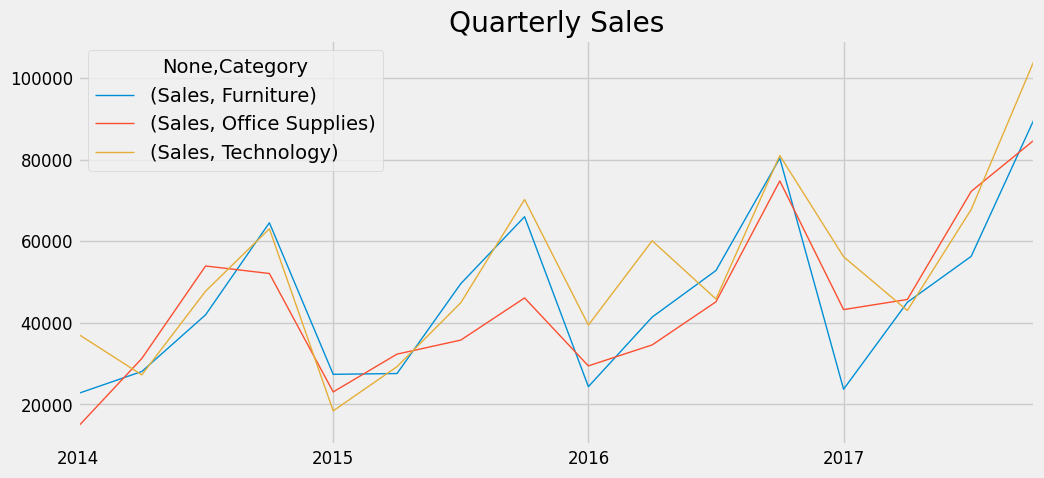

In [ ]:
pd.options.display.float_format = '{:,.1f}'.format

plotsize = (11, 5)
sales_quarterly.plot(figsize=plotsize, title='Quarterly Sales' , linewidth = 1.0)
#plt.title('Monthly Sales')



# Quarterly Sales Growth


<Axes: title={'center': 'Quarterly Sales % Change'}>

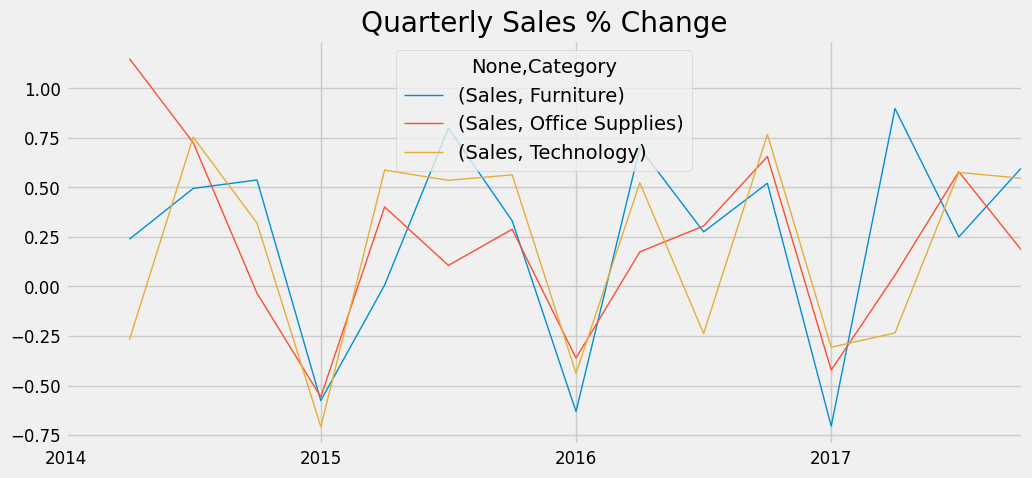

In [ ]:
sales_quarterly.pct_change().plot(figsize=plotsize, title='Quarterly Sales % Change' , linewidth = 1.0 )


## Time Series Visualizations


In [ ]:
sales_new.head()

Sales                           
Category   Furniture Office Supplies Technology
2014-01-03       0.0            16.4        0.0
2014-01-04       0.0           288.1        0.0
2014-01-05       0.0            19.5        0.0
2014-01-06   2,573.8           685.3    1,147.9
2014-01-07      76.7            10.4        0.0

Daily data Autocorrelation Plots


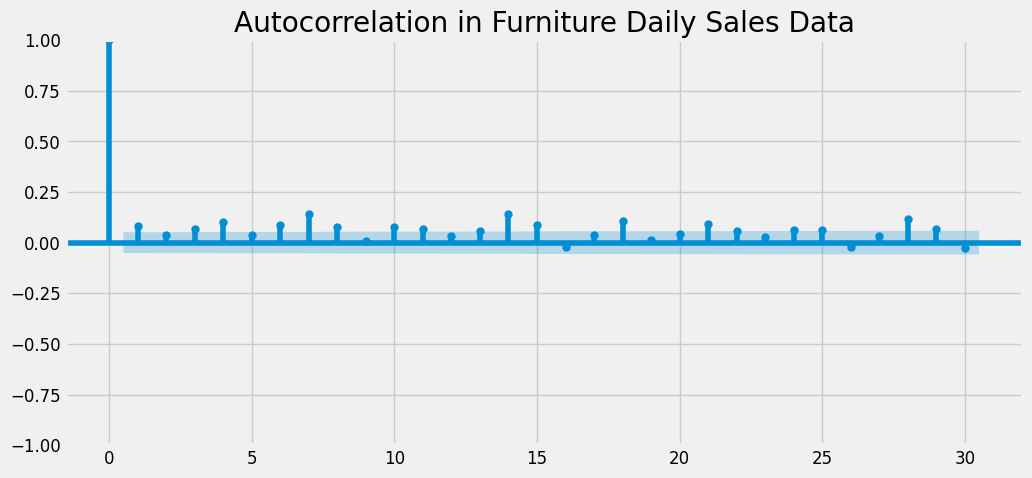

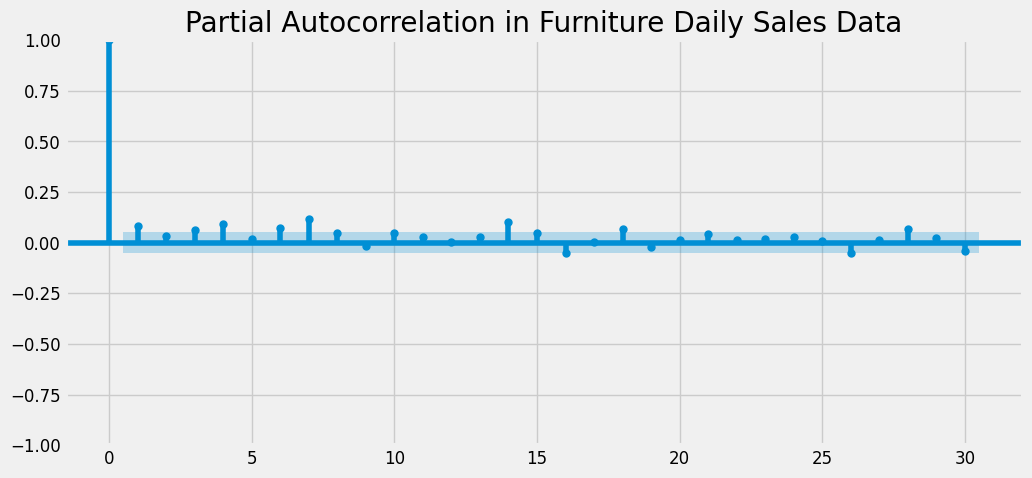

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot

print('Daily data Autocorrelation Plots')
# Autocorrelation and Partial Autocorrelation Functions for Daily Data
#plot_acf(sales_new['Sales']['Furniture'])
acf_plot = plot_acf(sales_new[('Sales' , 'Furniture')], lags=30, title='Autocorrelation in Furniture Daily Sales Data')
#plot_acf(sales_new['Sales']['Furniture'])
pacf_plot = plot_pacf(sales_new[('Sales' , 'Furniture')], lags=30, title='Partial Autocorrelation in Furniture Daily Sales Data')
#plot_acf(sales_new['Sales']['Furniture'])


Weekly data Autocorrelation Plots


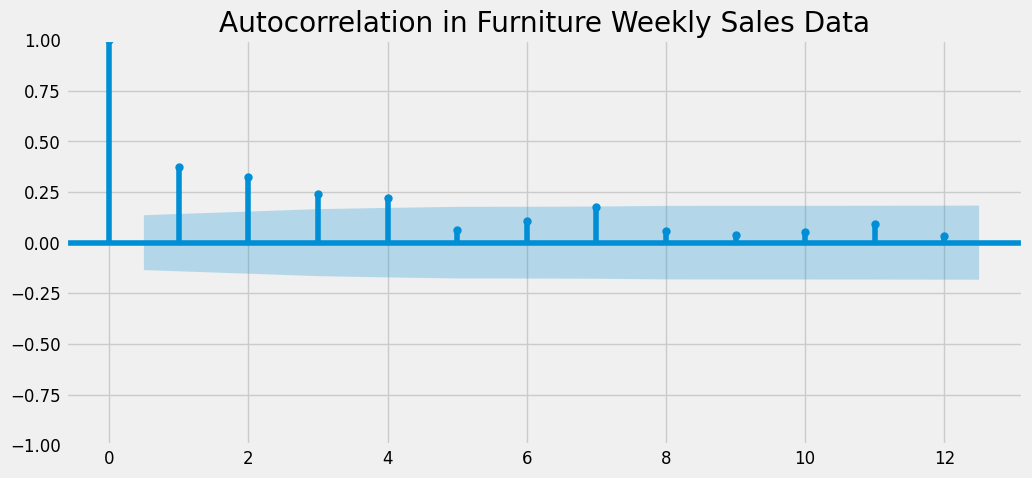

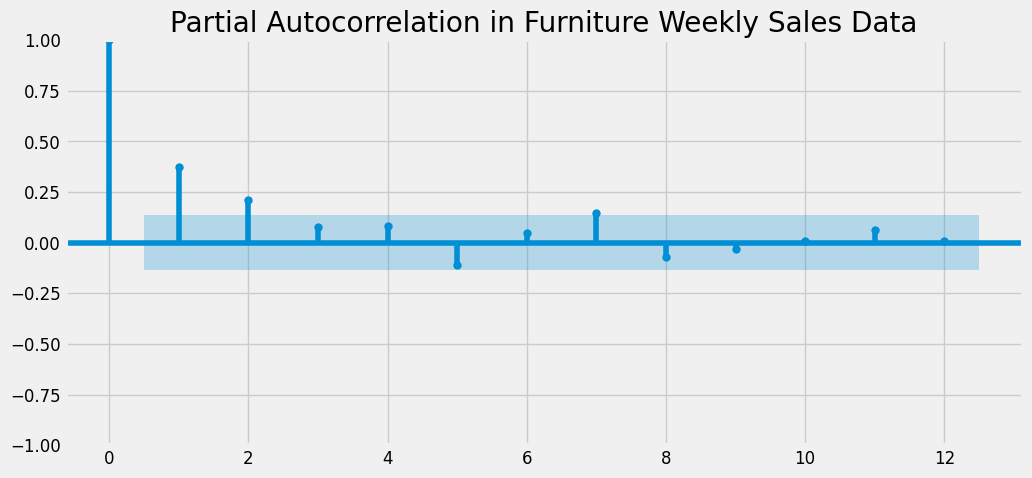

In [ ]:
print('\nWeekly data Autocorrelation Plots')
# Autocorrelation and Partial Autocorrelation Functions for Daily Data
#plot_acf(sales_new['Sales']['Furniture'])
acf_plot = plot_acf(sales_weekly[('Sales','Furniture')], lags=12, title='Autocorrelation in Furniture Weekly Sales Data')
#plot_acf(sales_new['Sales']['Furniture'])
pacf_plot = plot_pacf(sales_weekly['Sales','Furniture'], lags=12, title='Partial Autocorrelation in Furniture Weekly Sales Data')
#plot_acf(sales_new['Sales']['Furniture'])


monthly data Autocorrelation Plots


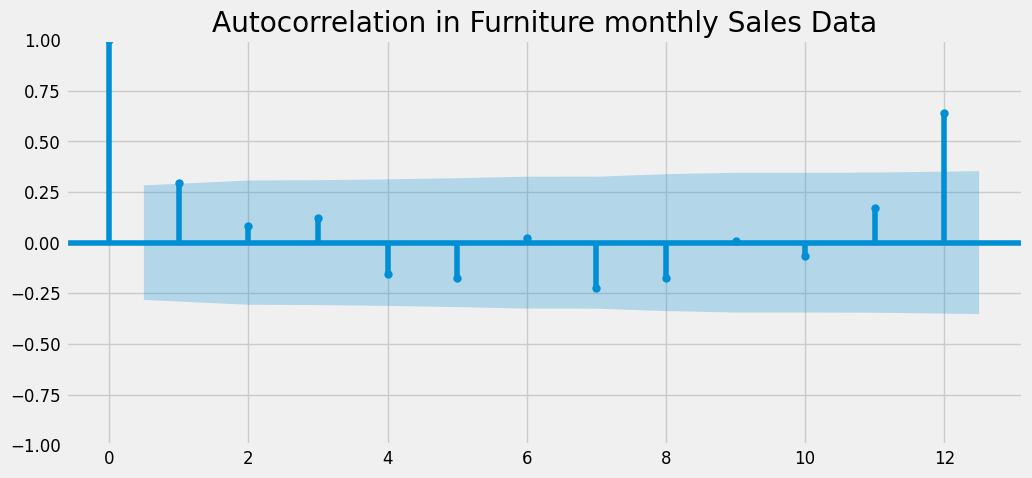

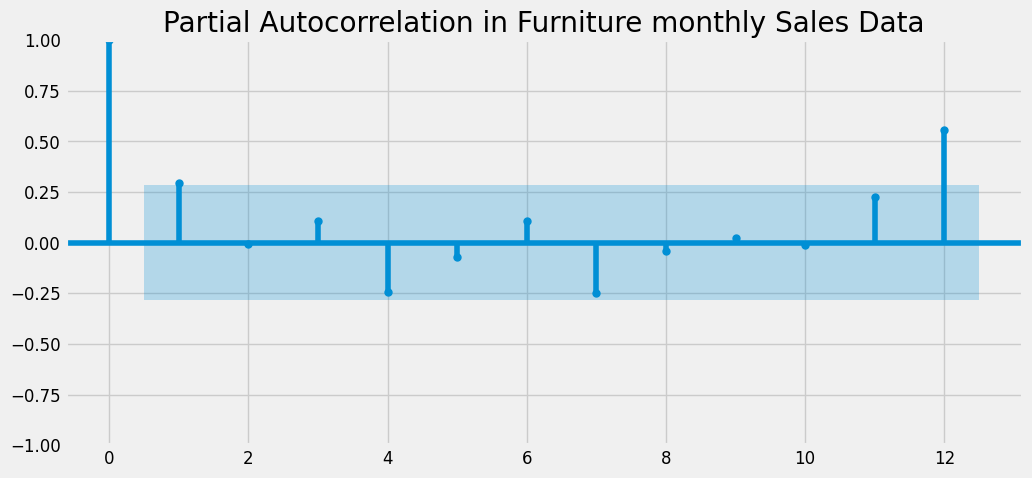

In [ ]:
print('\nmonthly data Autocorrelation Plots')
# Autocorrelation and Partial Autocorrelation Functions for monthly Data
#plot_acf(sales_new['Sales']['Furniture'])
acf_plot = plot_acf(sales_monthly[('Sales','Furniture')], lags=12, title='Autocorrelation in Furniture monthly Sales Data')
#plot_acf(sales_new['Sales']['Furniture'])
pacf_plot = plot_pacf(sales_monthly['Sales','Furniture'], lags=12, title='Partial Autocorrelation in Furniture monthly Sales Data')
#plot_acf(sales_new['Sales']['Furniture'])


Monthly Data Seasonal Plot


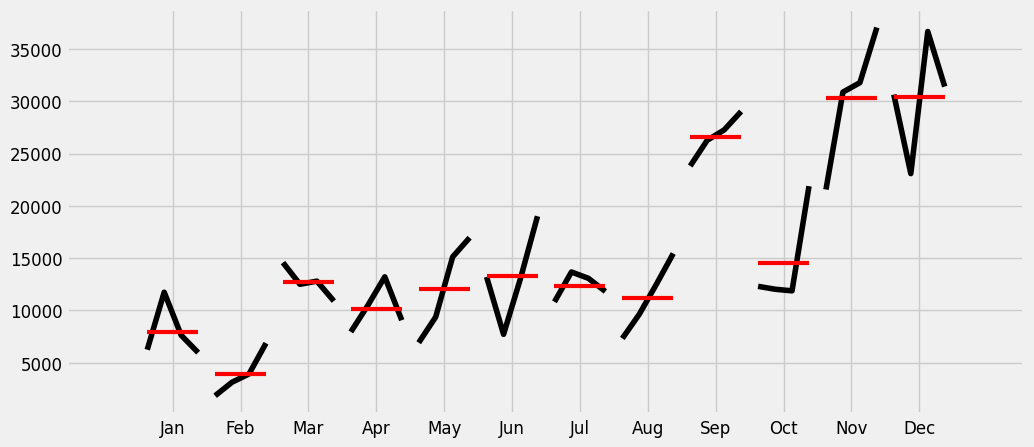

In [ ]:
print('\nMonthly Data Seasonal Plot')
m_plot = month_plot(sales_monthly[('Sales','Furniture')])

#Time  Series Decompostion

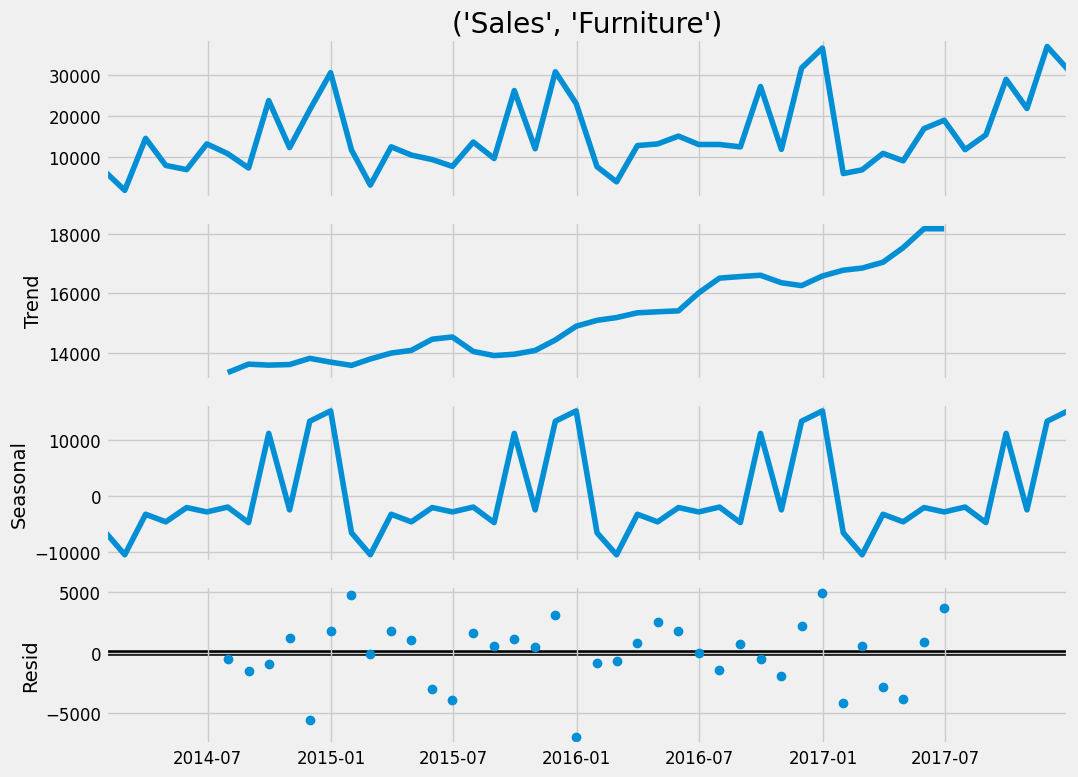

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 11, 8
decomposition = sm.tsa.seasonal_decompose(sales_monthly[('Sales','Furniture')], model='additive')
fig = decomposition.plot()
plt.show()

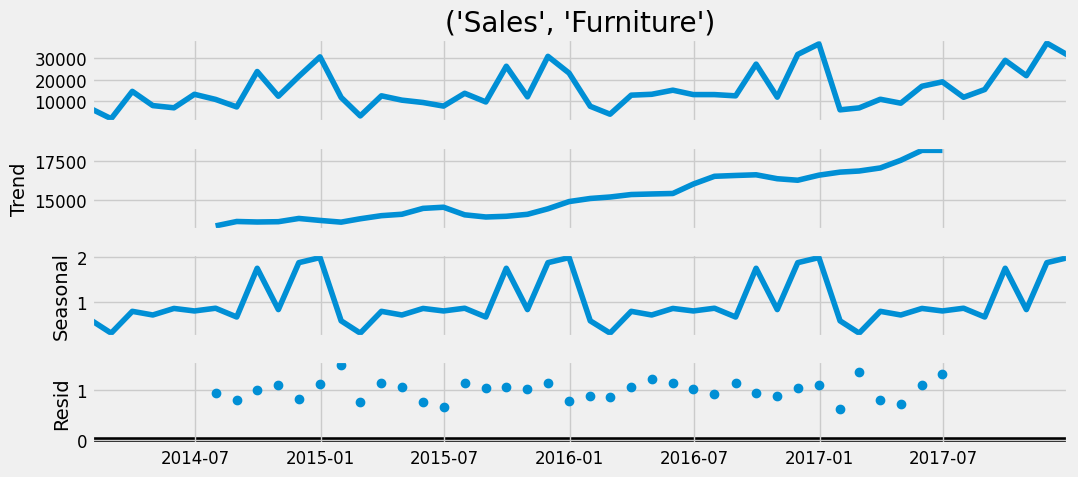

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 11, 5
decomposition = sm.tsa.seasonal_decompose(sales_monthly[('Sales','Furniture')], model='multiplicative')
fig = decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sales_monthly[('Sales','Furniture')])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))


ADF Statistic: -4.699026
p-value: 0.000085
Critical Values:
	1%: -3.578
	5%: -2.925
	10%: -2.601


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sales_weekly[('Sales','Furniture')])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))


ADF Statistic: -3.390631
p-value: 0.011282
Critical Values:
	1%: -3.463
	5%: -2.876
	10%: -2.574


In [ ]:
# Define the path where you want to save the Excel file
excel_file_path = 'preprocessdata.xlsx'  # Replace with your desired file path

# Save the DataFrame to an Excel file
sales_monthly.to_excel(excel_file_path)

print(f'Forecasted values saved to {excel_file_path}')

Forecasted values saved to preprocessdata.xlsx


#Navie Forecast on Multiplicative Model

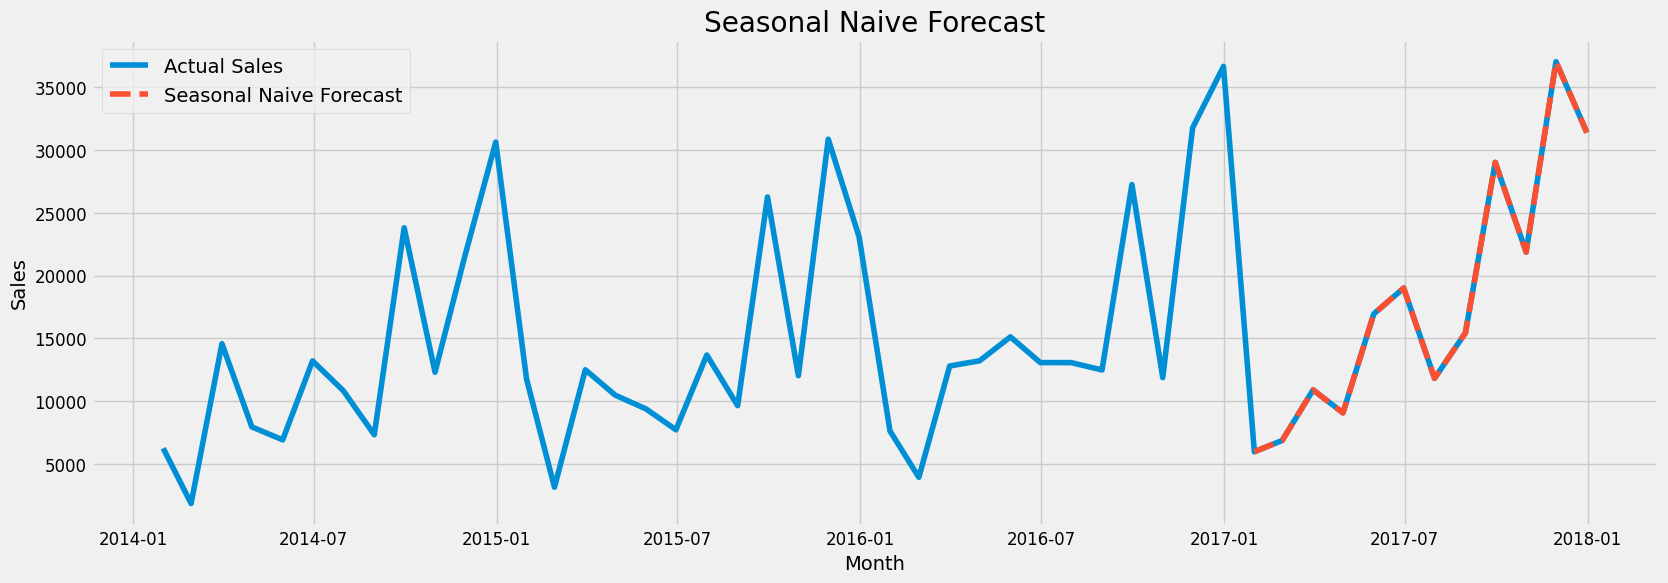

In [ ]:
# Seasonal Naive Forecast
# Assuming your data is monthly, so the seasonality period is 12 (for one year)
seasonality_period = 12

# Extract the last observed value for each season
last_observed_values = sales_monthly[('Sales','Furniture')][-seasonality_period:]

# Repeat these values for the forecast period (you can adjust the forecast horizon)
forecast_horizon = 12  # Adjust this as needed
seasonal_naive_forecast = last_observed_values.repeat(forecast_horizon)

# Plot the seasonal naive forecast
plt.figure(figsize=(18, 6))
plt.plot(sales_monthly[('Sales','Furniture')], label='Actual Sales')
plt.plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', linestyle='--')
plt.legend()
plt.title('Seasonal Naive Forecast')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [ ]:
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Define a function to find the optimal SARIMA parameters based on AIC or BIC
def find_optimal_sarima_parameters(data, seasonal_periods, max_p, max_d, max_q, max_P, max_D, max_Q, criterion='aic'):
    """
    data: Time series data as a pandas Series
    seasonal_periods: Number of seasonal periods (e.g., 12 for monthly data)
    max_p: Maximum AR order
    max_d: Maximum differencing order
    max_q: Maximum MA order
    max_P: Maximum seasonal AR order
    max_D: Maximum seasonal differencing order
    max_Q: Maximum seasonal MA order
    criterion: 'aic' for AIC or 'bic' for BIC
    """
    results = []
    for p in range(0, max_p + 1):
        for d in range(0, max_d + 1):
            for q in range(0, max_q + 1):
                for P in range(0, max_P + 1):
                    for D in range(0, max_D + 1):
                        for Q in range(0, max_Q + 1):
                            try:
                                model = sm.tsa.statespace.SARIMAX(data,
                                                                  order=(p, d, q),
                                                                  seasonal_order=(P, D, Q, seasonal_periods),
                                                                  enforce_stationarity=False,
                                                                  enforce_invertibility=False)
                                aic = model.fit().aic
                                results.append(((p, d, q, P, D, Q), aic))
                                print(f'SARIMA{(p, d, q)}x{(P, D, Q)}{seasonal_periods} - AIC: {aic:.2f}')
                            except:
                                continue

    # Find the SARIMA parameters with the lowest AIC or BIC
    optimal_params, optimal_criterion = min(results, key=lambda x: x[1])

    return optimal_params, optimal_criterion

# Example usage to find optimal SARIMA parameters based on AIC
furniture_sales = sales_monthly['Sales']['Furniture']  # Extract the 'Furniture' column
seasonal_periods = 12  # Monthly data
max_p = 1  # Maximum AR order
max_d = 1  # Maximum differencing order
max_q = 1  # Maximum MA order
max_P = 1  # Maximum seasonal AR order
max_D = 1  # Maximum seasonal differencing order
max_Q = 1  # Maximum seasonal MA order

optimal_sarima_params, optimal_sarima_criterion = find_optimal_sarima_parameters(
    furniture_sales, seasonal_periods, max_p, max_d, max_q, max_P, max_D, max_Q, criterion='aic')

print("Optimal SARIMA Parameters:", optimal_sarima_params)
print("Optimal SARIMA Criterion (AIC):", optimal_sarima_criterion)


SARIMA(0, 0, 0)x(0, 0, 0)12 - AIC: 1056.72
SARIMA(0, 0, 0)x(0, 0, 1)12 - AIC: 1481.26
SARIMA(0, 0, 0)x(0, 1, 0)12 - AIC: 691.39
SARIMA(0, 0, 0)x(0, 1, 1)12 - AIC: 458.13
SARIMA(0, 0, 0)x(1, 0, 0)12 - AIC: 711.25
SARIMA(0, 0, 0)x(1, 0, 1)12 - AIC: 1381.07
SARIMA(0, 0, 0)x(1, 1, 0)12 - AIC: 475.93
SARIMA(0, 0, 0)x(1, 1, 1)12 - AIC: 455.26
SARIMA(0, 0, 1)x(0, 0, 0)12 - AIC: 1015.76
SARIMA(0, 0, 1)x(0, 0, 1)12 - AIC: 5493.19
SARIMA(0, 0, 1)x(0, 1, 0)12 - AIC: 674.63
SARIMA(0, 0, 1)x(0, 1, 1)12 - AIC: 440.26
SARIMA(0, 0, 1)x(1, 0, 0)12 - AIC: 779.66
SARIMA(0, 0, 1)x(1, 0, 1)12 - AIC: 5152.97
SARIMA(0, 0, 1)x(1, 1, 0)12 - AIC: 476.78
SARIMA(0, 0, 1)x(1, 1, 1)12 - AIC: 438.26
SARIMA(0, 1, 0)x(0, 0, 0)12 - AIC: 984.87
SARIMA(0, 1, 0)x(0, 0, 1)12 - AIC: 1384.20
SARIMA(0, 1, 0)x(0, 1, 0)12 - AIC: 695.20
SARIMA(0, 1, 0)x(0, 1, 1)12 - AIC: 448.33
SARIMA(0, 1, 0)x(1, 0, 0)12 - AIC: 715.00
SARIMA(0, 1, 0)x(1, 0, 1)12 - AIC: 1361.22
SARIMA(0, 1, 0)x(1, 1, 0)12 - AIC: 465.70
SARIMA(0, 1, 0)x(1, 1, 1)1

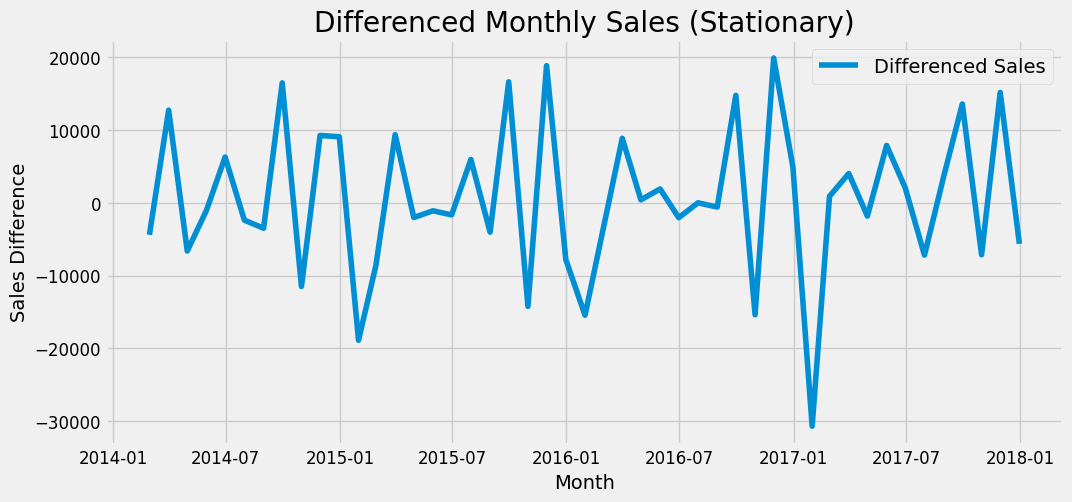

In [ ]:
# Take the first difference to remove the trend component
monthly_sales_diff = sales_monthly.diff(periods=1)

# Remove the NaN values generated by differencing
monthly_sales_diff = monthly_sales_diff.dropna()

# Plot the differenced data
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales_diff['Sales', 'Furniture'], label='Differenced Sales')
plt.title('Differenced Monthly Sales (Stationary)')
plt.xlabel('Month')
plt.ylabel('Sales Difference')
plt.legend()
plt.show()

# # Seasonality period
# seasonality_period = 12

# # First difference to remove trend
# monthly_sales_diff = sales_monthly.diff(periods=1)

# # Second difference to remove seasonality
# monthly_sales_diff = monthly_sales_diff.diff(periods=seasonality_period)

# # Remove the NaN values generated by differencing
# monthly_sales_diff = monthly_sales_diff.dropna()

# # Plot the differenced data with seasonality removed
# plt.figure(figsize=(11, 5))
# plt.plot(monthly_sales_diff['Sales', 'Furniture'], label='Differenced Sales (Seasonality Removed)')
# plt.title('Differenced Monthly Sales')
# plt.xlabel('Month')
# plt.ylabel('Sales Difference')
# plt.legend()
# plt.show()



In [ ]:
result = adfuller(monthly_sales_diff[('Sales','Furniture')])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.474589
p-value: 0.000000
Critical Values:
	1%: -3.627
	5%: -2.946
	10%: -2.612


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Define a function to find the optimal AR lag order based on AIC or BIC
def find_optimal_lag_order(data, max_lag, criterion='aic'):
    """
    data: Time series data as a pandas Series
    max_lag: Maximum number of lags to consider
    criterion: 'aic' for AIC or 'bic' for BIC
    """
    results = []
    for p in range(1, max_lag + 1):
        model = sm.tsa.AutoReg(data, lags=p).fit()
        if criterion == 'aic':
            results.append((p, model.aic))
        elif criterion == 'bic':
            results.append((p, model.bic))

    results_df = pd.DataFrame(results, columns=['Lag Order', criterion.upper()])

    # Find the lag order with the lowest AIC or BIC
    optimal_order = results_df.loc[results_df[criterion.upper()].idxmin()]

    return optimal_order

furniture_sales = monthly_sales_diff['Sales']['Furniture']  # Extract the 'Furniture' column

# Example usage to find optimal lag order based on AIC
max_lag = 12  # Maximum number of lags to consider
optimal_aic_order = find_optimal_lag_order(furniture_sales, max_lag, criterion='aic')
print("Optimal AIC Lag Order:", optimal_aic_order)

# Example usage to find optimal lag order based on BIC
optimal_bic_order = find_optimal_lag_order(furniture_sales, max_lag, criterion='bic')
print("Optimal BIC Lag Order:", optimal_bic_order)



Optimal AIC Lag Order: Lag Order    12.0
AIC         705.2
Name: 11, dtype: float64
Optimal BIC Lag Order: Lag Order    12.0
BIC         726.9
Name: 11, dtype: float64


#Here we identify that the Optimal lag number is 12

# **Implementation of the ARIMA model**



Mean Squared Error (MSE): 5082114.62
Root Mean Squared Error (RMSE): 2254.35


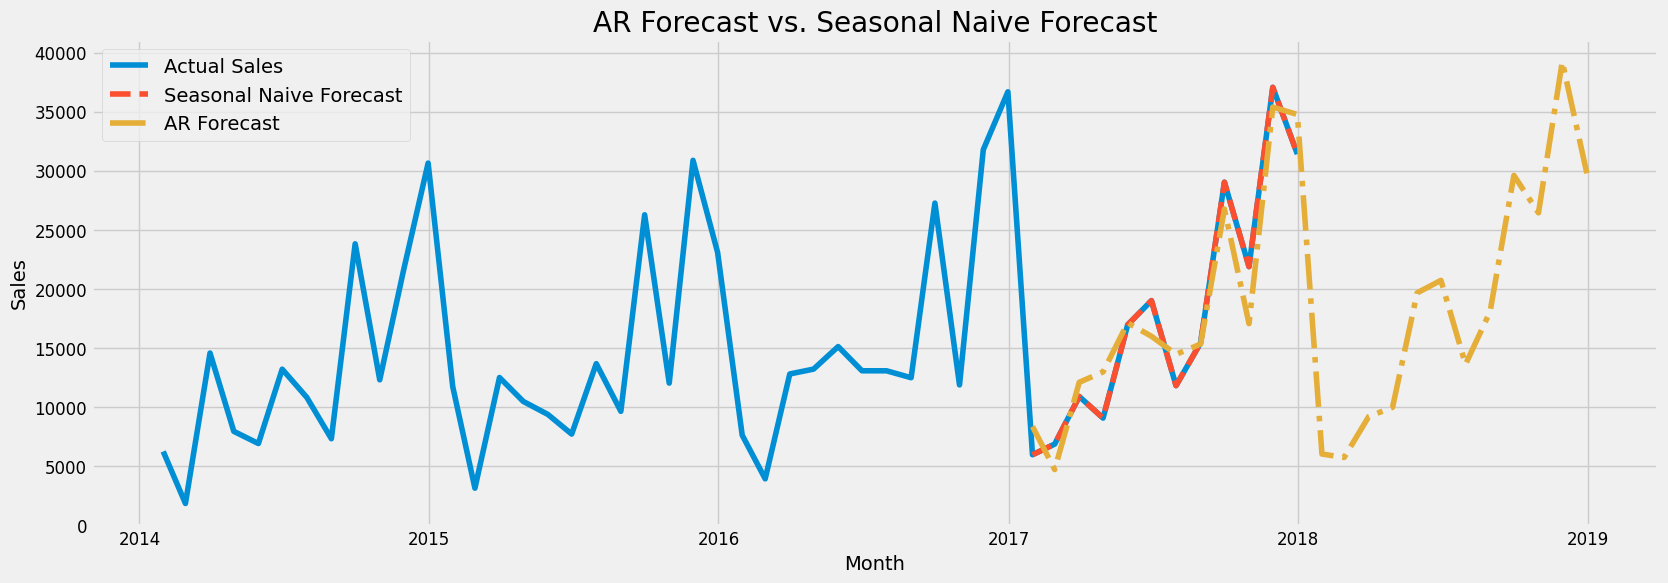

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
from math import sqrt

# Define a function to fit an AR model and make forecasts
def fit_ar_model(data, lag_order):
    model = AutoReg(data, lags=lag_order)
    model_fit = model.fit()
    return model_fit

def ar_forecast(model_fit, steps):
    forecast = model_fit.predict(start=len(model_fit.fittedvalues), end=len(model_fit.fittedvalues) + steps - 1, dynamic=False)
    return forecast

# Choose the lag order for your AR model (e.g., lag_order = 1)
lag_order = 12

# Fit the AR model to your monthly furniture sales data
furniture_sales = sales_monthly['Sales']['Furniture']  # Extract the 'Furniture' column
ar_model_fit = fit_ar_model(furniture_sales, lag_order)

# Specify the number of steps ahead you want to forecast
forecast_horizon = 24  # Adjust this as needed

# Make forecasts using the AR model
ar_forecasts = ar_forecast(ar_model_fit, forecast_horizon)

# Calculate Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)
actual_values = furniture_sales[-forecast_horizon:]
mse3 = mean_squared_error(actual_values, ar_forecasts)
rmse3 = sqrt(mse3)

print(f'Mean Squared Error (MSE): {mse3:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse3:.2f}')

# Plot the actual sales and AR model forecasts
plt.figure(figsize=(18, 6))
plt.plot(furniture_sales, label='Actual Sales')
plt.plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', linestyle='--')
plt.plot(ar_forecasts, label='AR Forecast', linestyle='-.')
plt.legend()
plt.title('AR Forecast vs. Seasonal Naive Forecast')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()


Mean Squared Error (MSE): 186859502.89
Root Mean Squared Error (RMSE): 13669.66


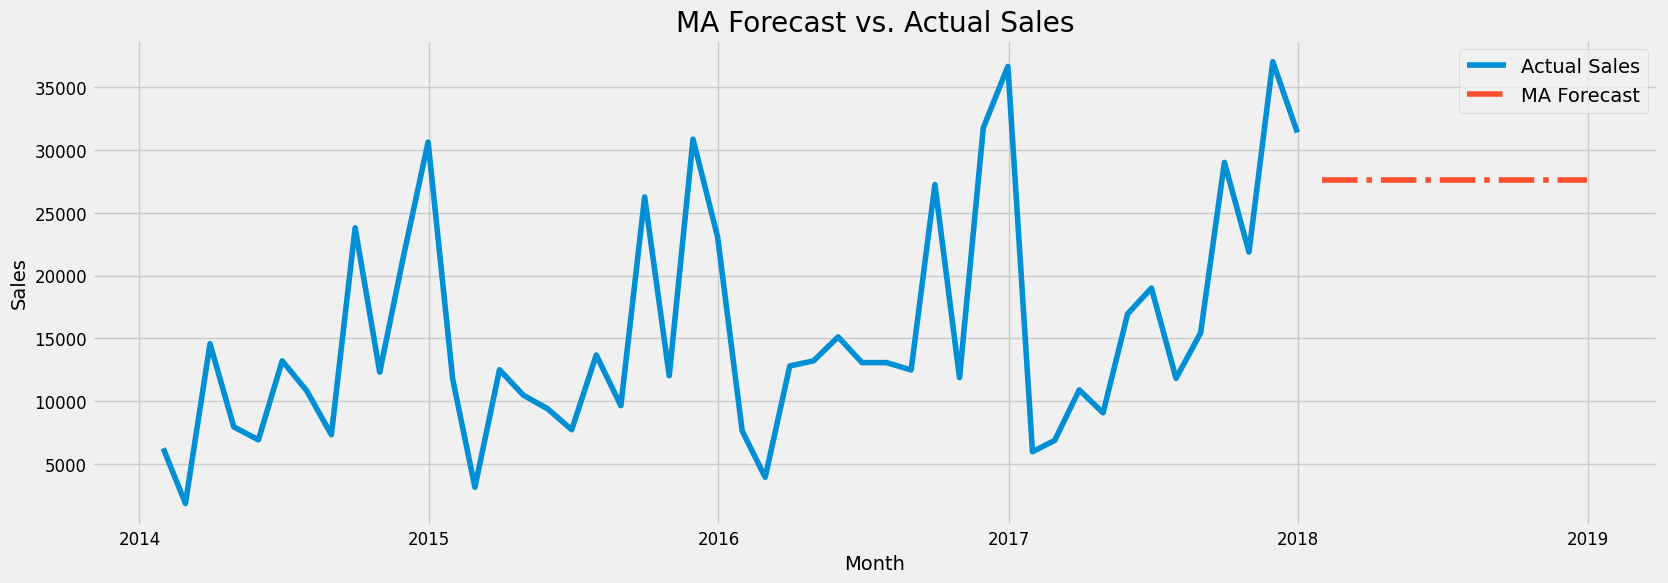

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt

# Define a function to fit an MA model and make forecasts
def fit_ma_model(data, order):
    p, d, q = order
    model = sm.tsa.ARIMA(data, order=(p, d, q))
    model_fit = model.fit()
    return model_fit

def ma_forecast(model_fit, steps):
    forecast = model_fit.forecast(steps=steps)
    return forecast

# Choose the order for your MA model (e.g., order=(0, 0, 1) for first-order MA)
ma_order = (0, 1, 1)  # Adjust this as needed

# Fit the MA model to your monthly furniture sales data
furniture_sales = sales_monthly['Sales']['Furniture']  # Extract the 'Furniture' column
ma_model_fit = fit_ma_model(furniture_sales, ma_order)

# Specify the number of steps ahead you want to forecast
forecast_horizon = 12  # Adjust this as needed

# Make forecasts using the MA model
ma_forecasts = ma_forecast(ma_model_fit, forecast_horizon)

# Calculate Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)
actual_values = furniture_sales[-forecast_horizon:]
mse2 = mean_squared_error(actual_values, ma_forecasts)
rmse2 = sqrt(mse2)

print(f'Mean Squared Error (MSE): {mse2:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse2:.2f}')

# Plot the actual sales and MA model forecasts
plt.figure(figsize=(18, 6))
plt.plot(furniture_sales, label='Actual Sales')
plt.plot(ma_forecasts, label='MA Forecast', linestyle='-.')
plt.legend()
plt.title('MA Forecast vs. Actual Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()


In [ ]:

# Define the ARIMA model with your variable
arima_order = (0, 1, 1)  # ARIMA order (p, d, q)
seasonal_order = (0, 1, 0, 12)  # Seasonal order (P, D, Q, seasonal_periods)
furniture_sales = monthly_sales_diff['Sales']['Furniture']  # Extract the 'Furniture' column

model = sm.tsa.statespace.SARIMAX(furniture_sales,
                                  order=arima_order,
                                  seasonal_order=seasonal_order,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

# Fit the ARIMA model
results = model.fit()

# Print the model summary
print(results.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9945      0.178     -5.596      0.000      -1.343      -0.646
sigma2      4.794e+07    2.3e-09   2.08e+16      0.000    4.79e+07    4.79e+07


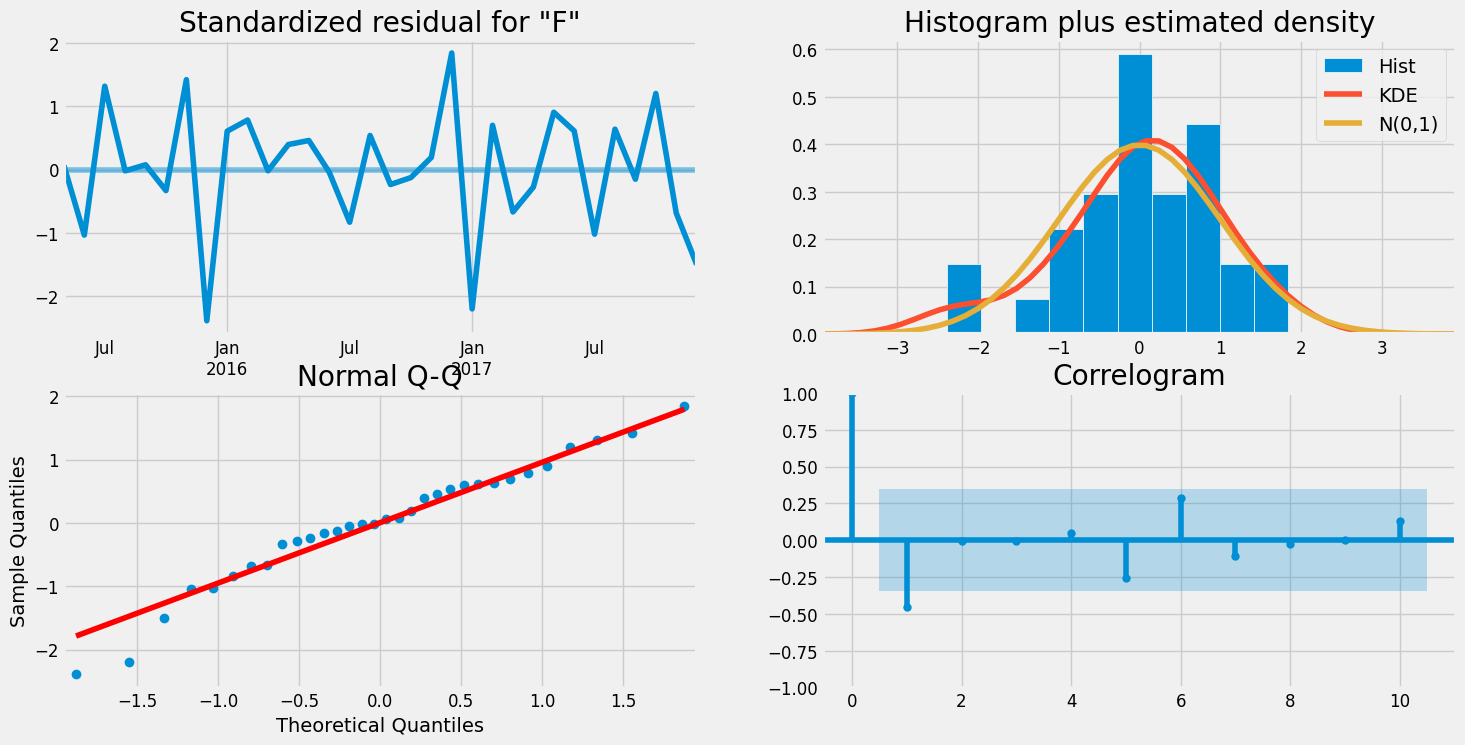

In [ ]:
import matplotlib.pyplot as plt

# Plot the model diagnostics
results.plot_diagnostics(figsize=(16, 8))
plt.show()


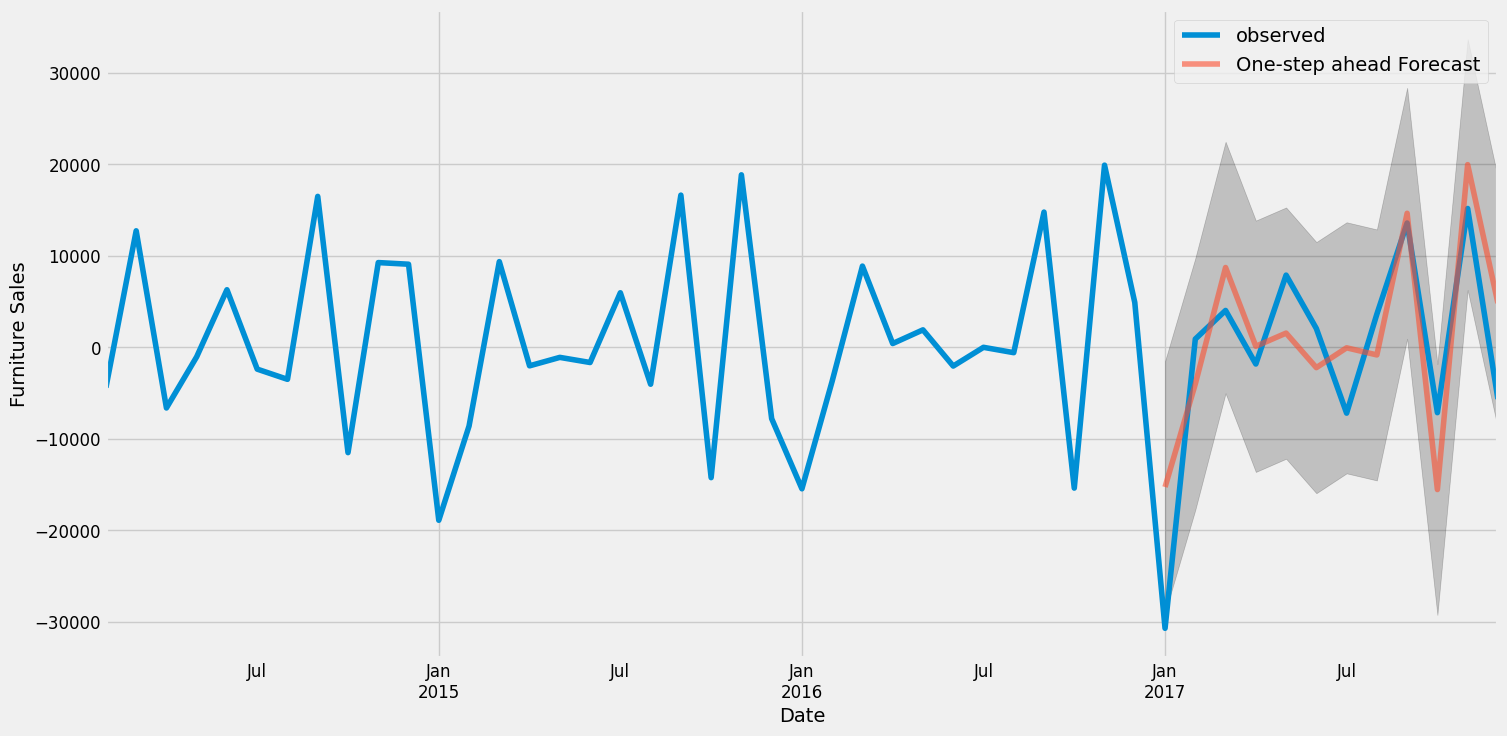

In [ ]:
# Find the index corresponding to '2017-01-01' or the nearest valid date
start_date = '2017-02-01'
valid_start_date = furniture_sales.index.get_loc(start_date, method='nearest')

# Use the valid start date in the prediction
prediction = results.get_prediction(start=valid_start_date, dynamic=False)
prediction_ci = prediction.conf_int()

ax = furniture_sales['2014':].plot(label='observed')
prediction.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.6, figsize=(16, 8))
ax.fill_between(prediction_ci.index,
                prediction_ci.iloc[:, 0],
                prediction_ci.iloc[:, 1], color='k', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()


##  The line plot is showing the observed values compared to the rolling forecast predictions. Overall, our forecasts align with the true values very well, showing an upward trend starts from the beginning of the year and captured the seasonality toward the end of the year.

In [ ]:
y_forecasted = prediction.predicted_mean
y_truth = furniture_sales['2017-02-01':]
mse1 = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse1, 2)))
print('The Root Mean Squared Error of our forecasts is {}'.format(round(np.sqrt(mse1), 2)))

The Mean Squared Error of our forecasts is 34895072.44
The Root Mean Squared Error of our forecasts is 5907.21


## Producing and visualizing forecasts


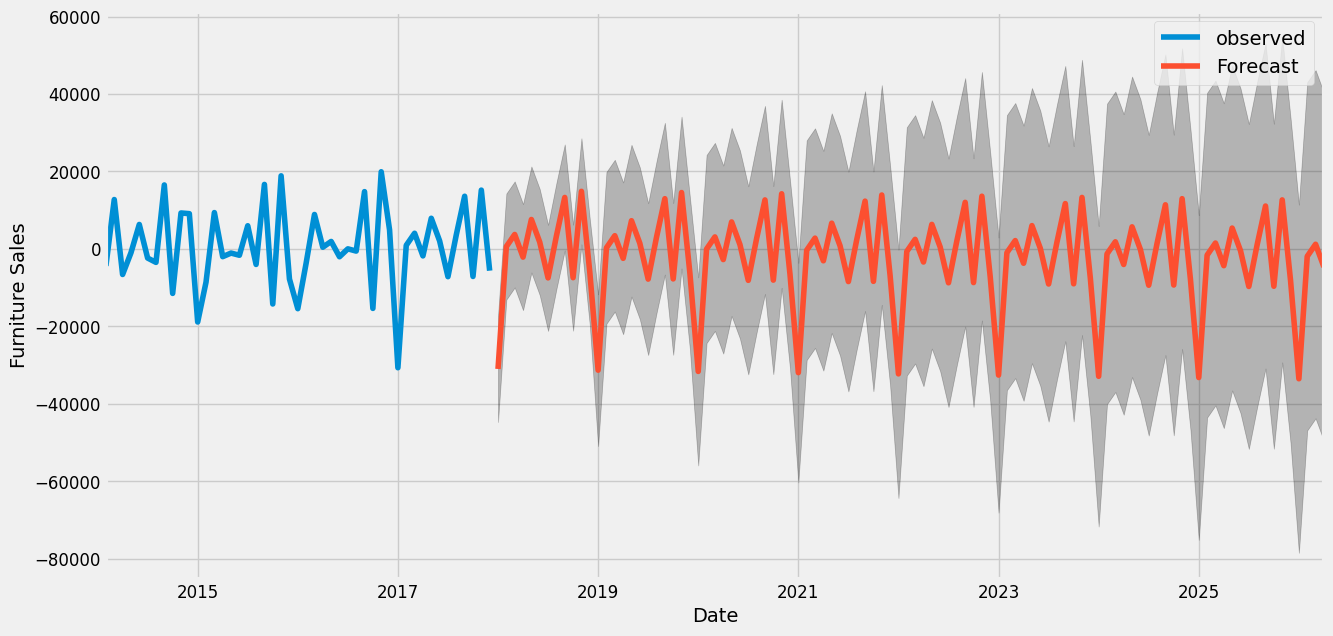

In [ ]:
# Define the number of steps to forecast (e.g., 100)
forecast_steps = 100

# Get the forecasted values and confidence intervals
pred_uc = results.get_forecast(steps=forecast_steps)
pred_ci = pred_uc.conf_int()

# Plot the observed data, forecasted values, and confidence intervals
ax = furniture_sales.plot(label='observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()
plt.show()


Our model clearly captured furniture sales seasonality. As we forecast further out into the future, it is natural for us to become less confident in our values. This is reflected by the confidence intervals generated by our model, which grow larger as we move further out into the future.

In [ ]:
forecasted_values = pred_uc.predicted_mean

# Create a DataFrame to store the forecasted values
forecast_df = pd.DataFrame({'Date': forecasted_values.index, 'Forecasted_Values': forecasted_values.values})
forecast_df['Date'] = forecast_df['Date'].astype(str)
# Define the path where you want to save the Excel file
excel_file_path = 'forecasted_values_furniture.xlsx'  # Replace with your desired file path

# Save the DataFrame to an Excel file
forecast_df.to_excel(excel_file_path, index=False)

print(f'Forecasted values saved to {excel_file_path}')


Forecasted values saved to forecasted_values_furniture.xlsx


In [ ]:
forecast_df.head()

,Date,Forecasted_Values
0,2018-01-31,"-31,030.7"
1,2018-02-28,586.3
2,2018-03-31,"3,711.1"
3,2018-04-30,"-2,143.5"
4,2018-05-31,"7,575.6"


## **OFFICE SUPPLIES**

In [ ]:
Office_Supplies_sales = sales_monthly['Sales']['Office Supplies']

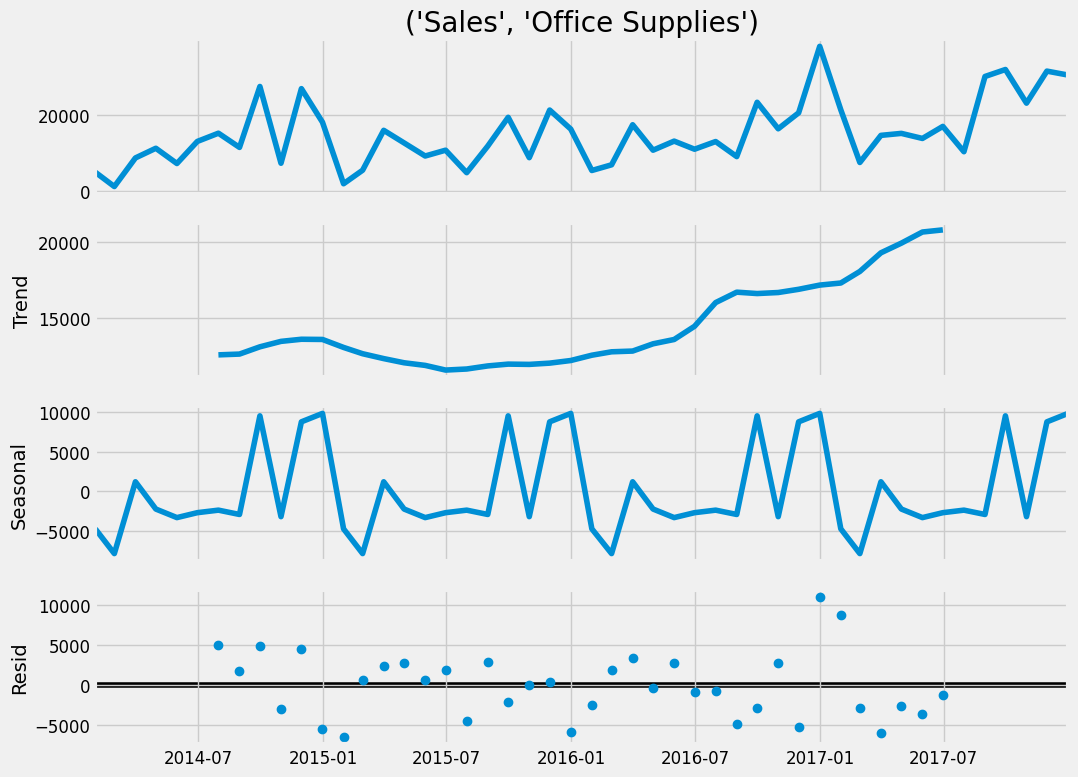

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 11, 8
decomposition = sm.tsa.seasonal_decompose(sales_monthly[('Sales','Office Supplies')], model='additive')
fig = decomposition.plot()
plt.show()

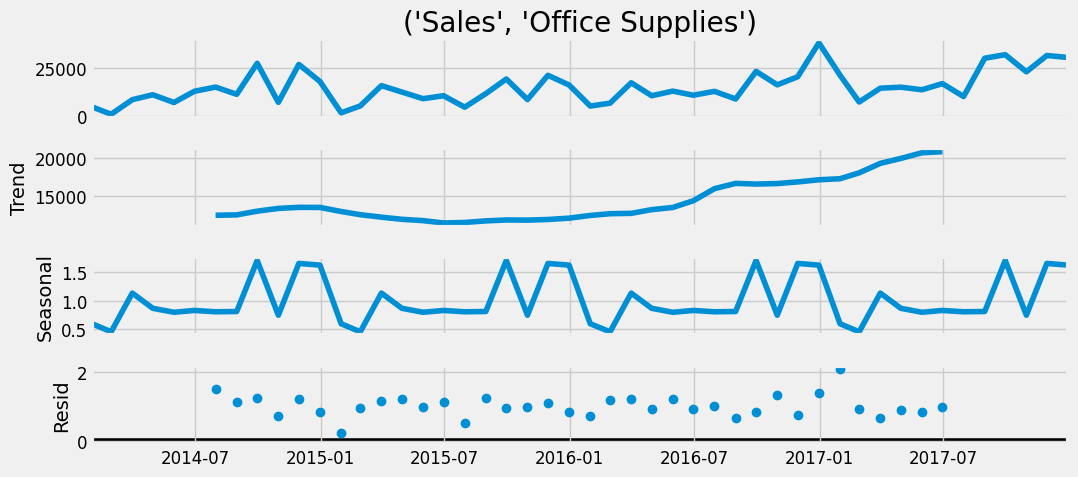

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 11, 5
decomposition = sm.tsa.seasonal_decompose(sales_monthly[('Sales','Office Supplies')], model='multiplicative')
fig = decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sales_monthly[('Sales','Office Supplies')])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -1.905481
p-value: 0.329487
Critical Values:
	1%: -3.585
	5%: -2.928
	10%: -2.602


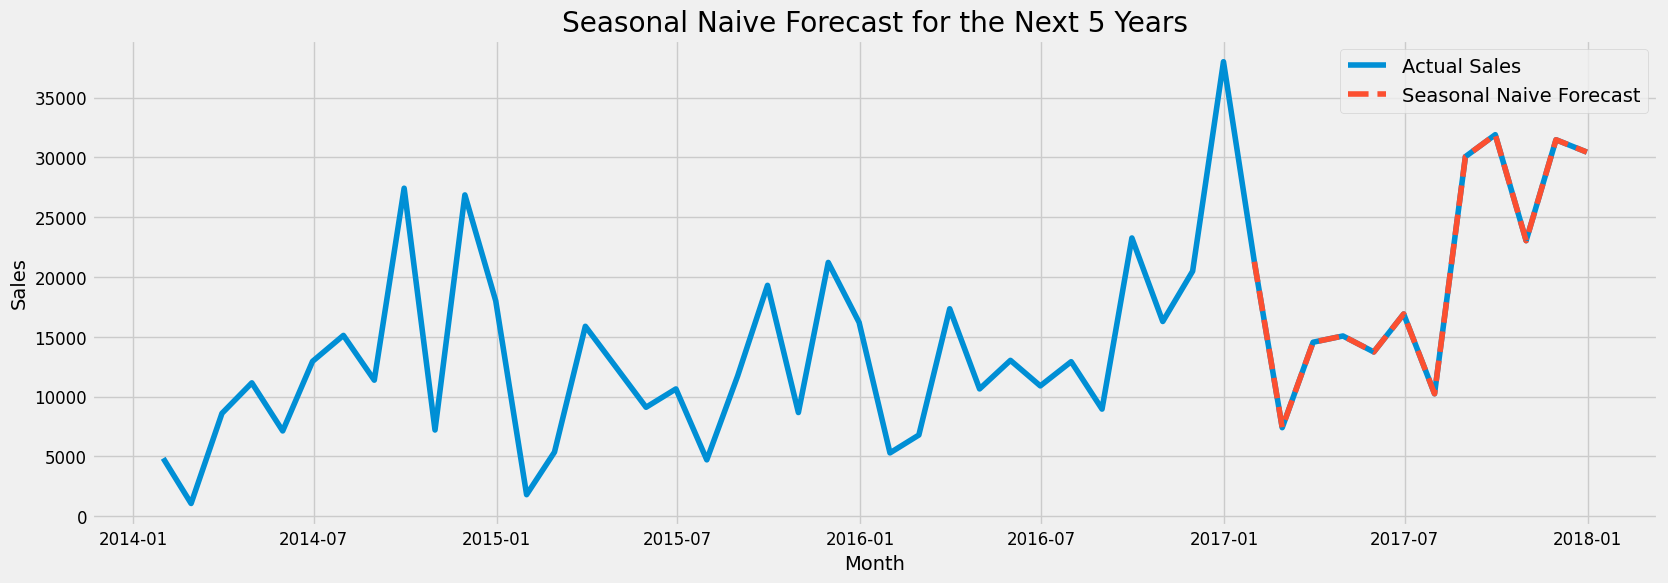

In [ ]:
# Seasonal Naive Forecast
# Assuming your data is monthly, so the seasonality period is 12 (for one year)
seasonality_period = 12

# Extract the last observed value for each season
last_observed_values = sales_monthly[('Sales','Office Supplies')][-seasonality_period:]

# Extend the forecast horizon to 60 months (5 years)
forecast_horizon = 60  # Adjust this for the desired forecast period (5 years)

# Repeat the last observed values for the forecast period
seasonal_naive_forecast = last_observed_values.repeat(forecast_horizon)

# Plot the seasonal naive forecast for the next 5 years
plt.figure(figsize=(18, 6))
plt.plot(sales_monthly[('Sales','Office Supplies')], label='Actual Sales')
plt.plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', linestyle='--')
plt.legend()
plt.title('Seasonal Naive Forecast for the Next 5 Years')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Define a function to find the optimal SARIMA parameters based on AIC or BIC
def find_optimal_sarima_parameters(data, seasonal_periods, max_p, max_d, max_q, max_P, max_D, max_Q, criterion='aic'):
    """
    data: Time series data as a pandas Series
    seasonal_periods: Number of seasonal periods (e.g., 12 for monthly data)
    max_p: Maximum AR order
    max_d: Maximum differencing order
    max_q: Maximum MA order
    max_P: Maximum seasonal AR order
    max_D: Maximum seasonal differencing order
    max_Q: Maximum seasonal MA order
    criterion: 'aic' for AIC or 'bic' for BIC
    """
    results = []
    for p in range(0, max_p + 1):
        for d in range(0, max_d + 1):
            for q in range(0, max_q + 1):
                for P in range(0, max_P + 1):
                    for D in range(0, max_D + 1):
                        for Q in range(0, max_Q + 1):
                            try:
                                model = sm.tsa.statespace.SARIMAX(data,
                                                                  order=(p, d, q),
                                                                  seasonal_order=(P, D, Q, seasonal_periods),
                                                                  enforce_stationarity=False,
                                                                  enforce_invertibility=False)
                                aic = model.fit().aic
                                results.append(((p, d, q, P, D, Q), aic))
                                print(f'SARIMA{(p, d, q)}x{(P, D, Q)}{seasonal_periods} - AIC: {aic:.2f}')
                            except:
                                continue

    # Find the SARIMA parameters with the lowest AIC or BIC
    optimal_params, optimal_criterion = min(results, key=lambda x: x[1])

    return optimal_params, optimal_criterion

# Example usage to find optimal SARIMA parameters based on AIC
Office_Supplies_sales = sales_monthly['Sales']['Office Supplies']
seasonal_periods = 12  # Monthly data
max_p = 1  # Maximum AR order
max_d = 1  # Maximum differencing order
max_q = 1  # Maximum MA order
max_P = 1  # Maximum seasonal AR order
max_D = 1  # Maximum seasonal differencing order
max_Q = 1  # Maximum seasonal MA order

optimal_sarima_params, optimal_sarima_criterion = find_optimal_sarima_parameters(
    Office_Supplies_sales , seasonal_periods, max_p, max_d, max_q, max_P, max_D, max_Q, criterion='aic')

print("Optimal SARIMA Parameters:", optimal_sarima_params)
print("Optimal SARIMA Criterion (AIC):", optimal_sarima_criterion)


SARIMA(0, 0, 0)x(0, 0, 0)12 - AIC: 1053.04
SARIMA(0, 0, 0)x(0, 0, 1)12 - AIC: 1136.27
SARIMA(0, 0, 0)x(0, 1, 0)12 - AIC: 727.00
SARIMA(0, 0, 0)x(0, 1, 1)12 - AIC: 485.84
SARIMA(0, 0, 0)x(1, 0, 0)12 - AIC: 747.94
SARIMA(0, 0, 0)x(1, 0, 1)12 - AIC: 721.79
SARIMA(0, 0, 0)x(1, 1, 0)12 - AIC: 505.42
SARIMA(0, 0, 0)x(1, 1, 1)12 - AIC: 489.28
SARIMA(0, 0, 1)x(0, 0, 0)12 - AIC: 1011.57
SARIMA(0, 0, 1)x(0, 0, 1)12 - AIC: 5448.78
SARIMA(0, 0, 1)x(0, 1, 0)12 - AIC: 707.17
SARIMA(0, 0, 1)x(0, 1, 1)12 - AIC: 465.72
SARIMA(0, 0, 1)x(1, 0, 0)12 - AIC: 782.07
SARIMA(0, 0, 1)x(1, 0, 1)12 - AIC: 699.21
SARIMA(0, 0, 1)x(1, 1, 0)12 - AIC: 503.97
SARIMA(0, 0, 1)x(1, 1, 1)12 - AIC: 466.32
SARIMA(0, 1, 0)x(0, 0, 0)12 - AIC: 974.88
SARIMA(0, 1, 0)x(0, 0, 1)12 - AIC: 1400.31
SARIMA(0, 1, 0)x(0, 1, 0)12 - AIC: 719.72
SARIMA(0, 1, 0)x(0, 1, 1)12 - AIC: 464.03
SARIMA(0, 1, 0)x(1, 0, 0)12 - AIC: 728.84
SARIMA(0, 1, 0)x(1, 0, 1)12 - AIC: 1434.04
SARIMA(0, 1, 0)x(1, 1, 0)12 - AIC: 486.79
SARIMA(0, 1, 0)x(1, 1, 1)12 

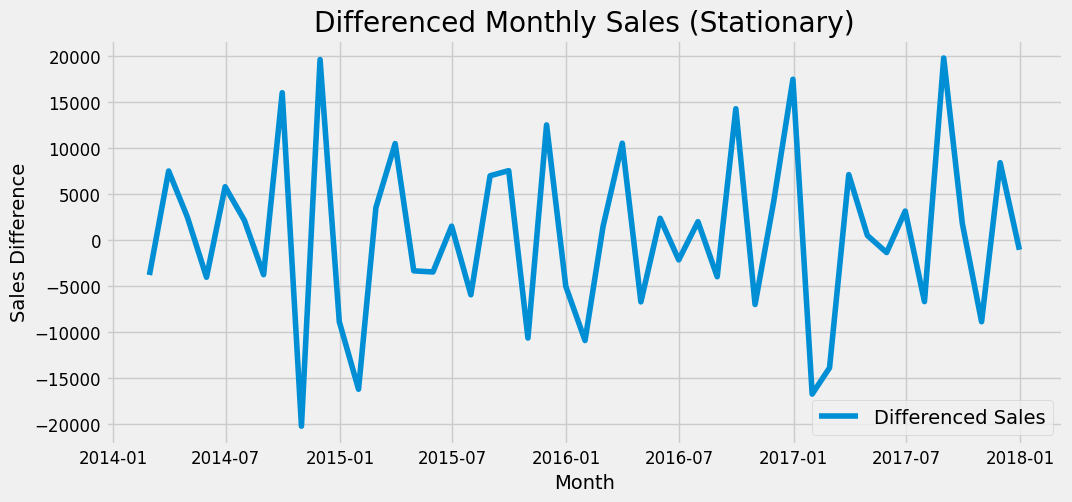

In [ ]:
# Take the first difference to remove the trend component
monthly_sales_diff = sales_monthly.diff(periods=1)

# Remove the NaN values generated by differencing
monthly_sales_diff = monthly_sales_diff.dropna()

# Plot the differenced data
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales_diff['Sales', 'Office Supplies'], label='Differenced Sales')
plt.title('Differenced Monthly Sales (Stationary)')
plt.xlabel('Month')
plt.ylabel('Sales Difference')
plt.legend()
plt.show()


In [ ]:
# # Seasonality period
# seasonality_period = 12

# # First difference to remove trend
# monthly_sales_diff = sales_monthly.diff(periods=1)

# # Second difference to remove seasonality
# monthly_sales_diff = monthly_sales_diff.diff(periods=seasonality_period)

# # Remove the NaN values generated by differencing
# monthly_sales_diff = monthly_sales_diff.dropna()

# # Plot the differenced data with seasonality removed
# plt.figure(figsize=(11, 5))
# plt.plot(monthly_sales_diff['Sales', 'Office Supplies'], label='Differenced Sales (Seasonality Removed)')
# plt.title('Differenced Monthly Sales')
# plt.xlabel('Month')
# plt.ylabel('Sales Difference')
# plt.legend()
# plt.show()

In [ ]:
result = adfuller(monthly_sales_diff[('Sales','Office Supplies')])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.308890
p-value: 0.000429
Critical Values:
	1%: -3.627
	5%: -2.946
	10%: -2.612


In [ ]:
# Define the ARIMA model with your variable
arima_order = (0, 1, 1)  # ARIMA order (p, d, q)
seasonal_order = (0, 1, 0, 12)  # Seasonal order (P, D, Q, seasonal_periods)
Office_Supplies_sales = sales_monthly['Sales']['Office Supplies']

model = sm.tsa.statespace.SARIMAX(furniture_sales,
                                  order=arima_order,
                                  seasonal_order=seasonal_order,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

# Fit the ARIMA model
results2 = model.fit()

# Print the model summary
print(results2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9945      0.178     -5.596      0.000      -1.343      -0.646
sigma2      4.794e+07    2.3e-09   2.08e+16      0.000    4.79e+07    4.79e+07


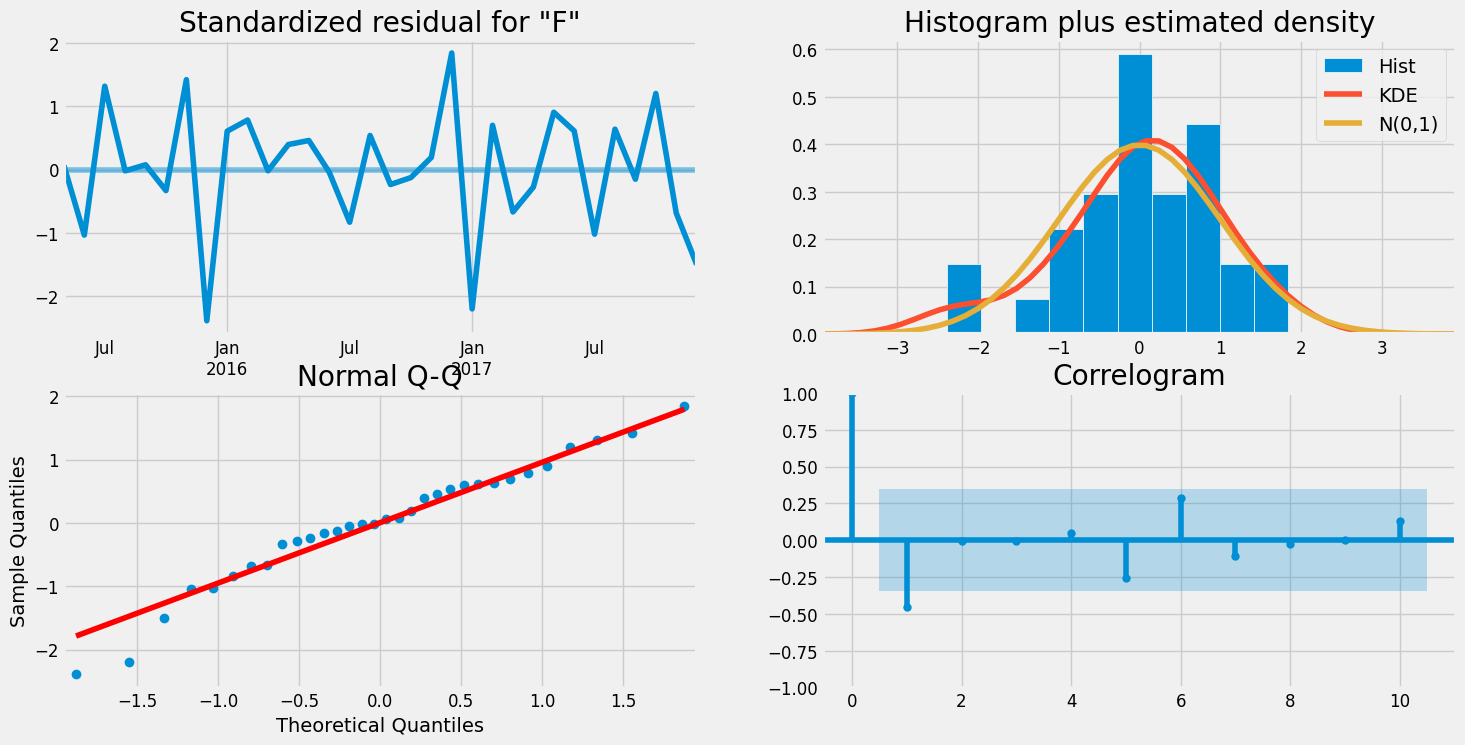

In [ ]:
import matplotlib.pyplot as plt

# Plot the model diagnostics
results2.plot_diagnostics(figsize=(16, 8))
plt.show()

In [ ]:
Office_Supplies_sales_diff = monthly_sales_diff['Sales', 'Office Supplies']

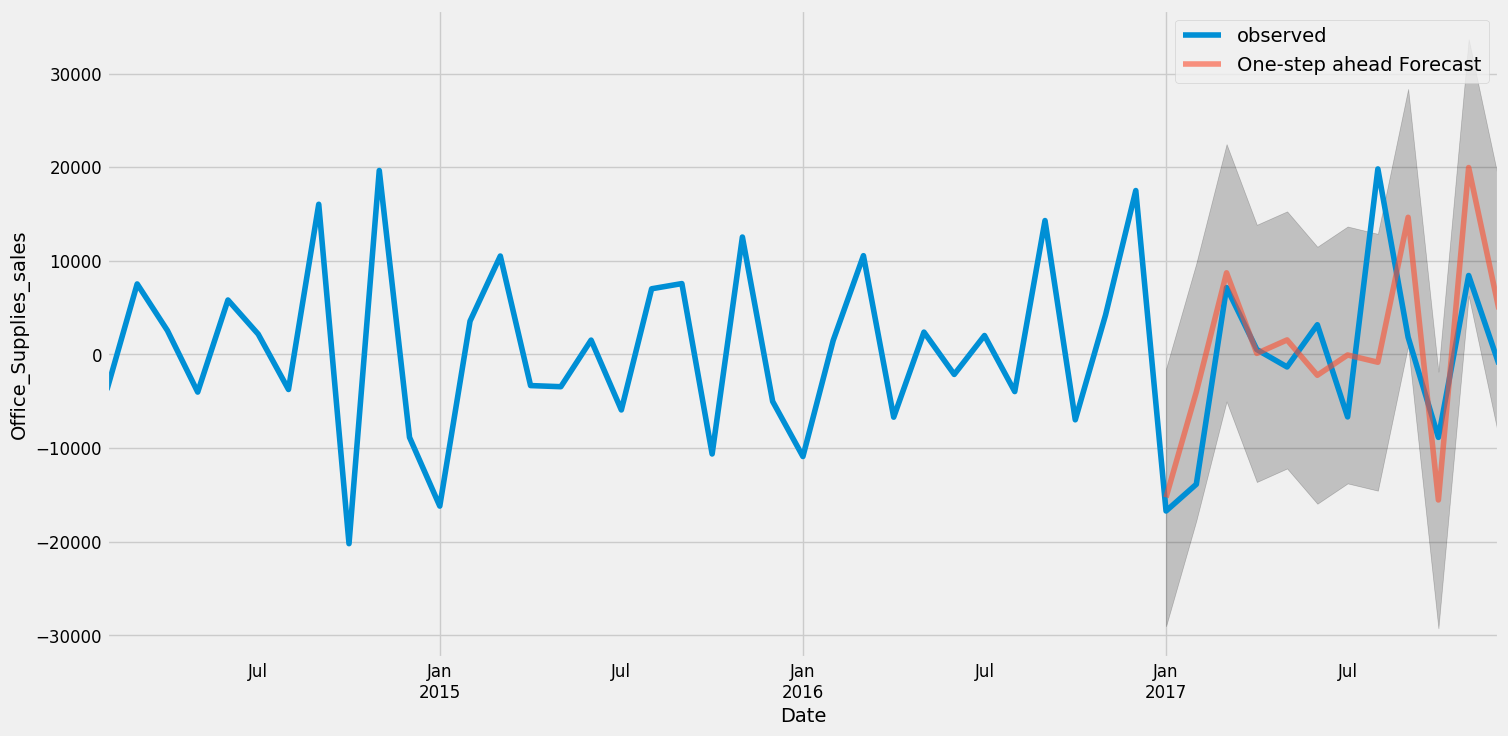

In [ ]:
# Find the index corresponding to '2017-01-01' or the nearest valid date
start_date = '2017-02-01'
valid_start_date = Office_Supplies_sales_diff.index.get_loc(start_date, method='nearest')

# Use the valid start date in the prediction
prediction = results2.get_prediction(start=valid_start_date, dynamic=False)
prediction_ci = prediction.conf_int()

ax = Office_Supplies_sales_diff['2014':].plot(label='observed')
prediction.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.6, figsize=(16, 8))
ax.fill_between(prediction_ci.index,
                prediction_ci.iloc[:, 0],
                prediction_ci.iloc[:, 1], color='k', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('Office_Supplies_sales')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Define the observed values and forecasted values
observed_values = Office_Supplies_sales_diff['2017-01-01':]  # Replace with your actual data
forecasted_values = prediction.predicted_mean

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(observed_values, forecasted_values)

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f'The Mean Squared Error (MSE) is: {mse:.2f}')
print(f'The Root Mean Squared Error (RMSE) is: {rmse:.2f}')


The Mean Squared Error (MSE) is: 82173862.10
The Root Mean Squared Error (RMSE) is: 9064.98


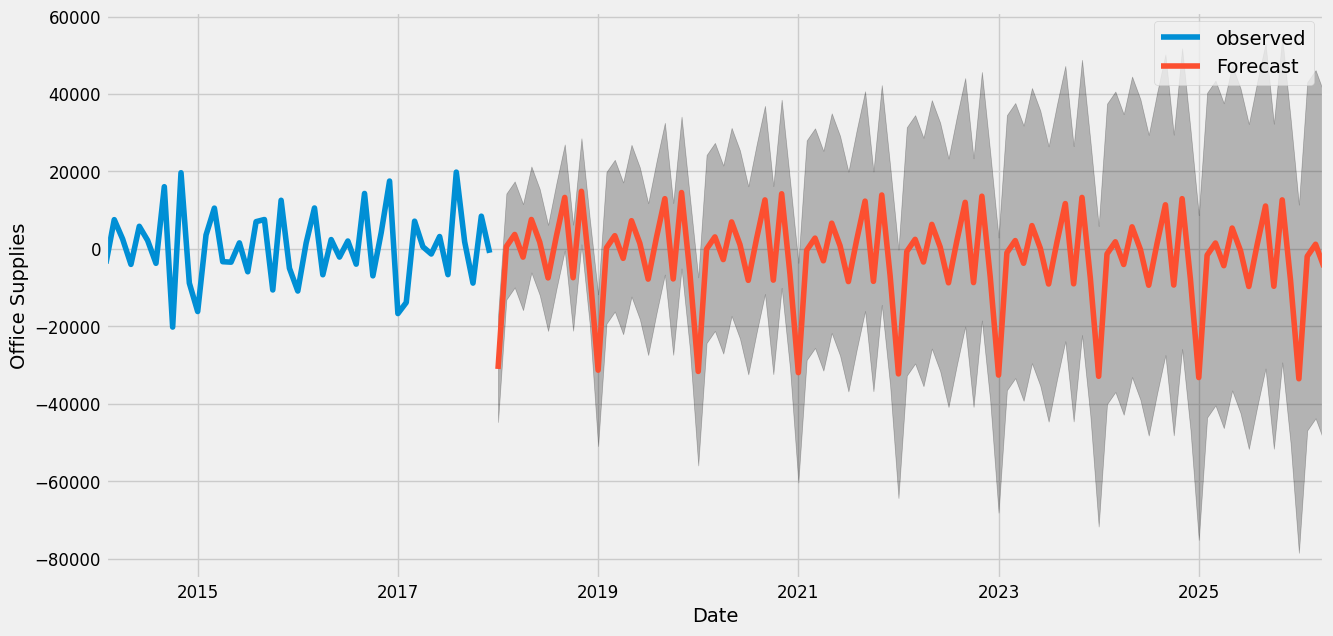

In [ ]:
# Define the number of steps to forecast (e.g., 100)
forecast_steps = 100

# Get the forecasted values and confidence intervals
pred_uc2 = results2.get_forecast(steps=forecast_steps)
pred_ci2 = pred_uc2.conf_int()

# Plot the observed data, forecasted values, and confidence intervals
ax = Office_Supplies_sales_diff.plot(label='observed', figsize=(14, 7))
pred_uc2.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci2.index,
                pred_ci2.iloc[:, 0],
                pred_ci2.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies')
plt.legend()
plt.show()


In [ ]:
forecasted_values1 = pred_uc2.predicted_mean

# Create a DataFrame to store the forecasted values
forecast_df1 = pd.DataFrame({'Date': forecasted_values1.index, 'Forecasted_Values': forecasted_values1.values})
forecast_df1['Date'] = forecast_df1['Date'].astype(str)

# Define the path where you want to save the Excel file
excel_file_path = 'forecasted_values_officesupplies.xlsx'  # Replace with your desired file path

# Save the DataFrame to an Excel file
forecast_df1.to_excel(excel_file_path, index=False)

print(f'Forecasted values saved to {excel_file_path}')


Forecasted values saved to forecasted_values_officesupplies.xlsx


In [ ]:
forecast_df1.head()

,Date,Forecasted_Values
0,2018-01-31,"-31,030.7"
1,2018-02-28,586.3
2,2018-03-31,"3,711.1"
3,2018-04-30,"-2,143.5"
4,2018-05-31,"7,575.6"


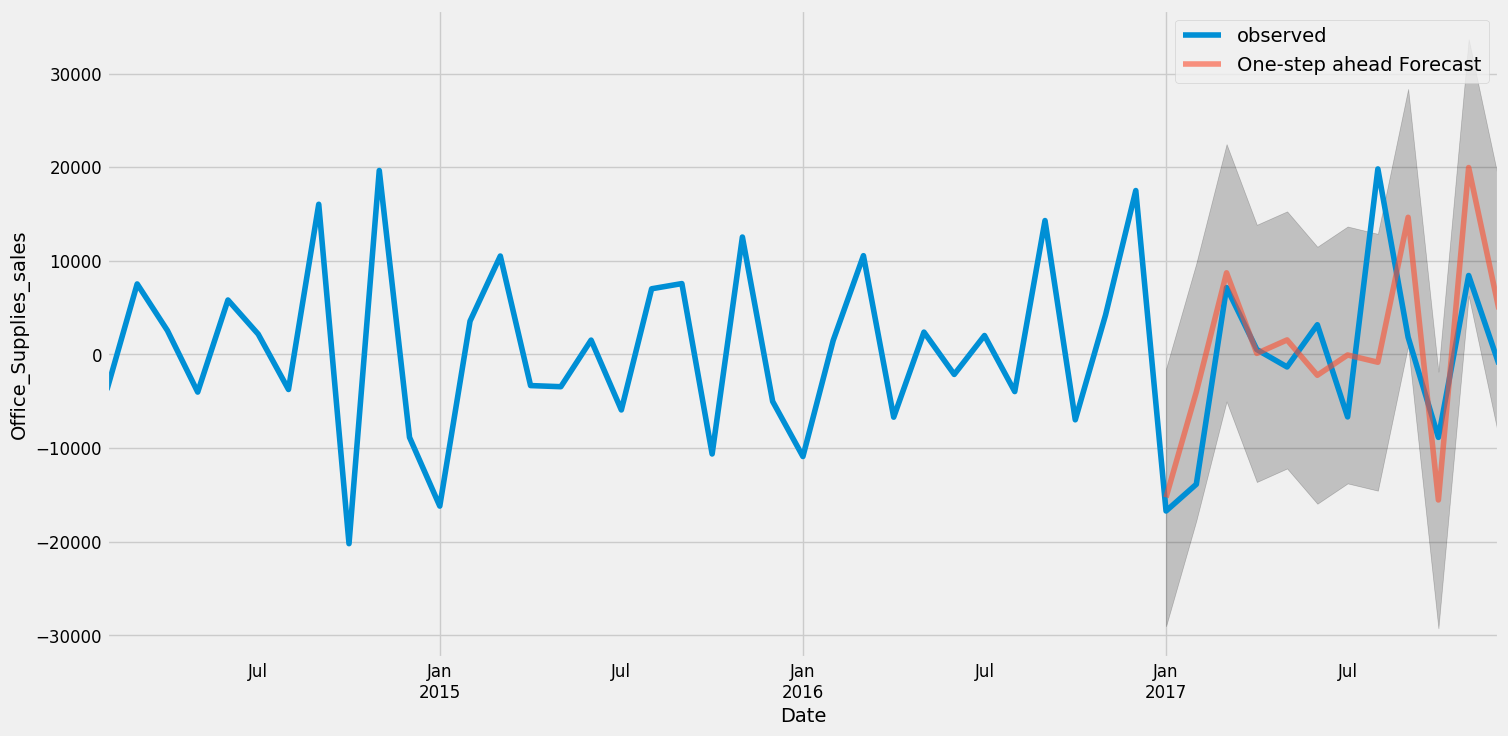

In [ ]:
# Find the index corresponding to '2017-01-01' or the nearest valid date
start_date = '2017-02-01'
valid_start_date = Office_Supplies_sales_diff.index.get_loc(start_date, method='nearest')

# Use the valid start date in the prediction
prediction = results2.get_prediction(start=valid_start_date, dynamic=False)
prediction_ci = prediction.conf_int()

ax = Office_Supplies_sales_diff['2014':].plot(label='observed')
prediction.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.6, figsize=(16, 8))
ax.fill_between(prediction_ci.index,
                prediction_ci.iloc[:, 0],
                prediction_ci.iloc[:, 1], color='k', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('Office_Supplies_sales')
plt.legend()
plt.show()

#**Thank You**